🚀 炼丹炉就绪! 算力: cuda
📡 锁定的 15% PMU 观测点: [0, 2, 8, 18]
📥 正在读取 50,000 条 33 节点物理样本...

🔥 启动基态深度训练 (对齐鲁棒性配置 150 轮)...
Epoch 0   | Avg Loss: 49783.9308 | LR: 1.000000e-03
Epoch 30  | Avg Loss: 105.5511 | LR: 1.000000e-03
Epoch 60  | Avg Loss: 241.6763 | LR: 5.000000e-04
Epoch 90  | Avg Loss: 230.2833 | LR: 2.500000e-04
Epoch 120 | Avg Loss: 230.2326 | LR: 1.250000e-04
Epoch 149 | Avg Loss: 230.1148 | LR: 1.250000e-04

🏆 [基态验收 终极对账] Overall MAE: 2.158649e-02 p.u. | RMSE: 2.562303e-02 p.u.

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🛡️ Phase 1: Zero-shot 零样本断线对账 (无 TTA)
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🔬 [NO TTA] 场景: C1 (Cut 7-8)
   • MAE:  1.354204e-02 p.u. | RMSE: 1.989614e-02 p.u. | RSE: 2.460840e-02
   🚫 物理死区识别: 节点 [ 8  9 10 11 12 13 14 15 16 17]


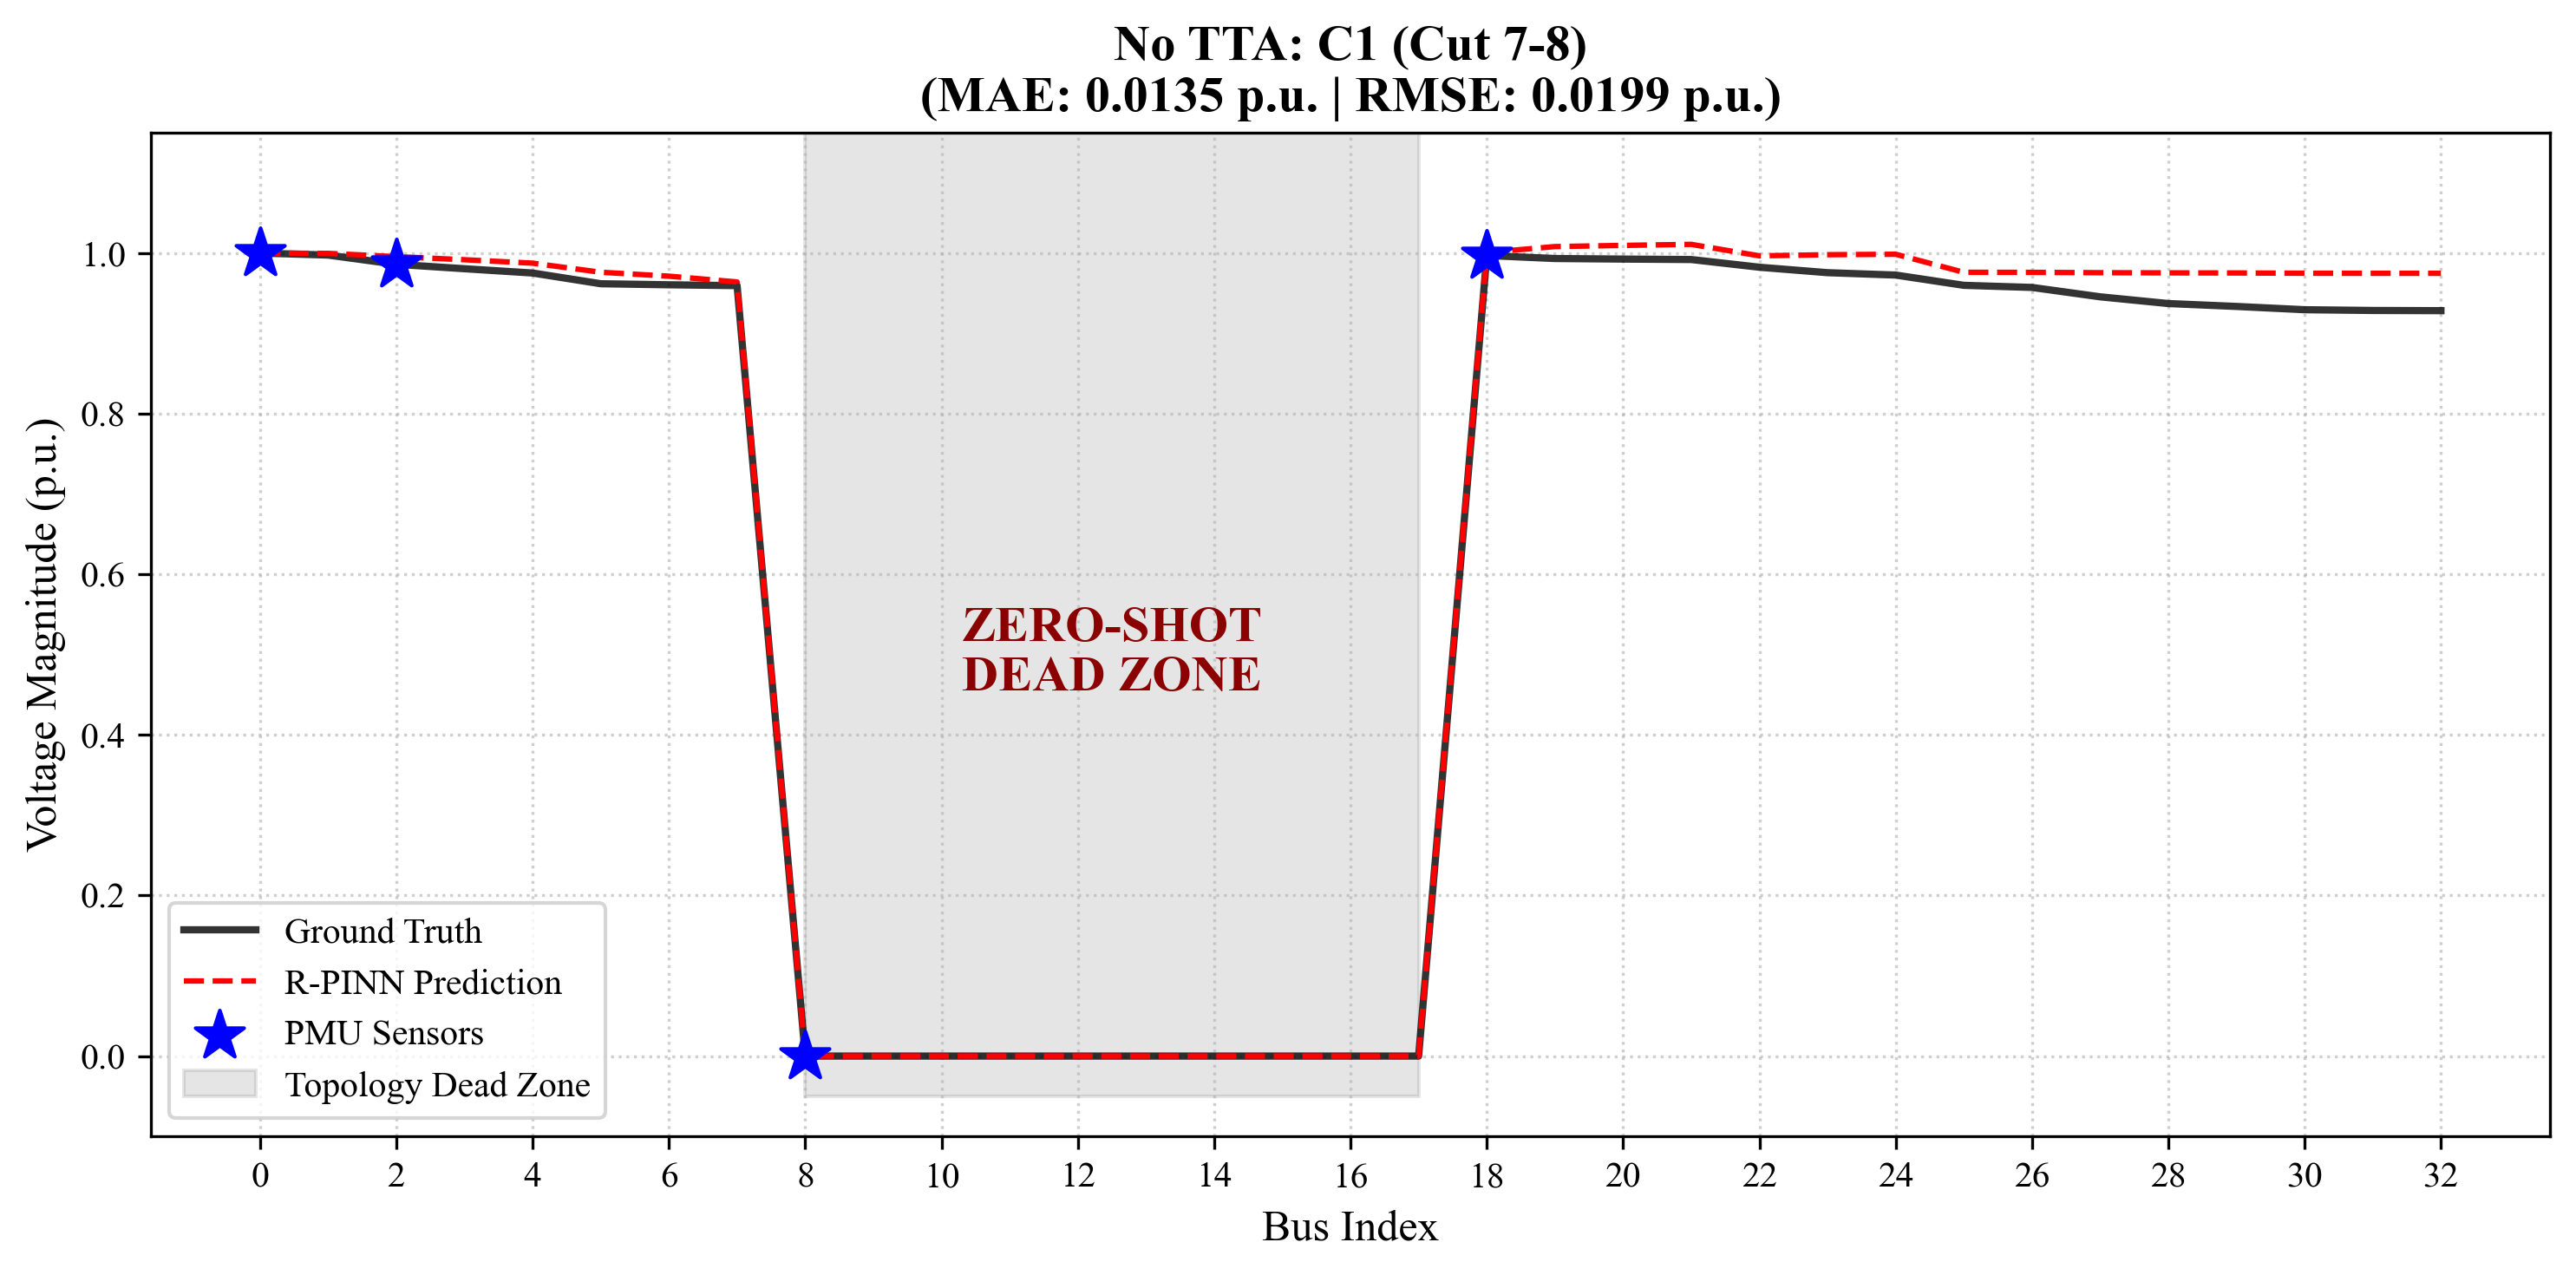


🔬 [NO TTA] 场景: C2 (Cut 13-14)
   • MAE:  1.802265e-02 p.u. | RMSE: 2.327285e-02 p.u. | RSE: 2.589318e-02
   🚫 物理死区识别: 节点 [14 15 16 17]


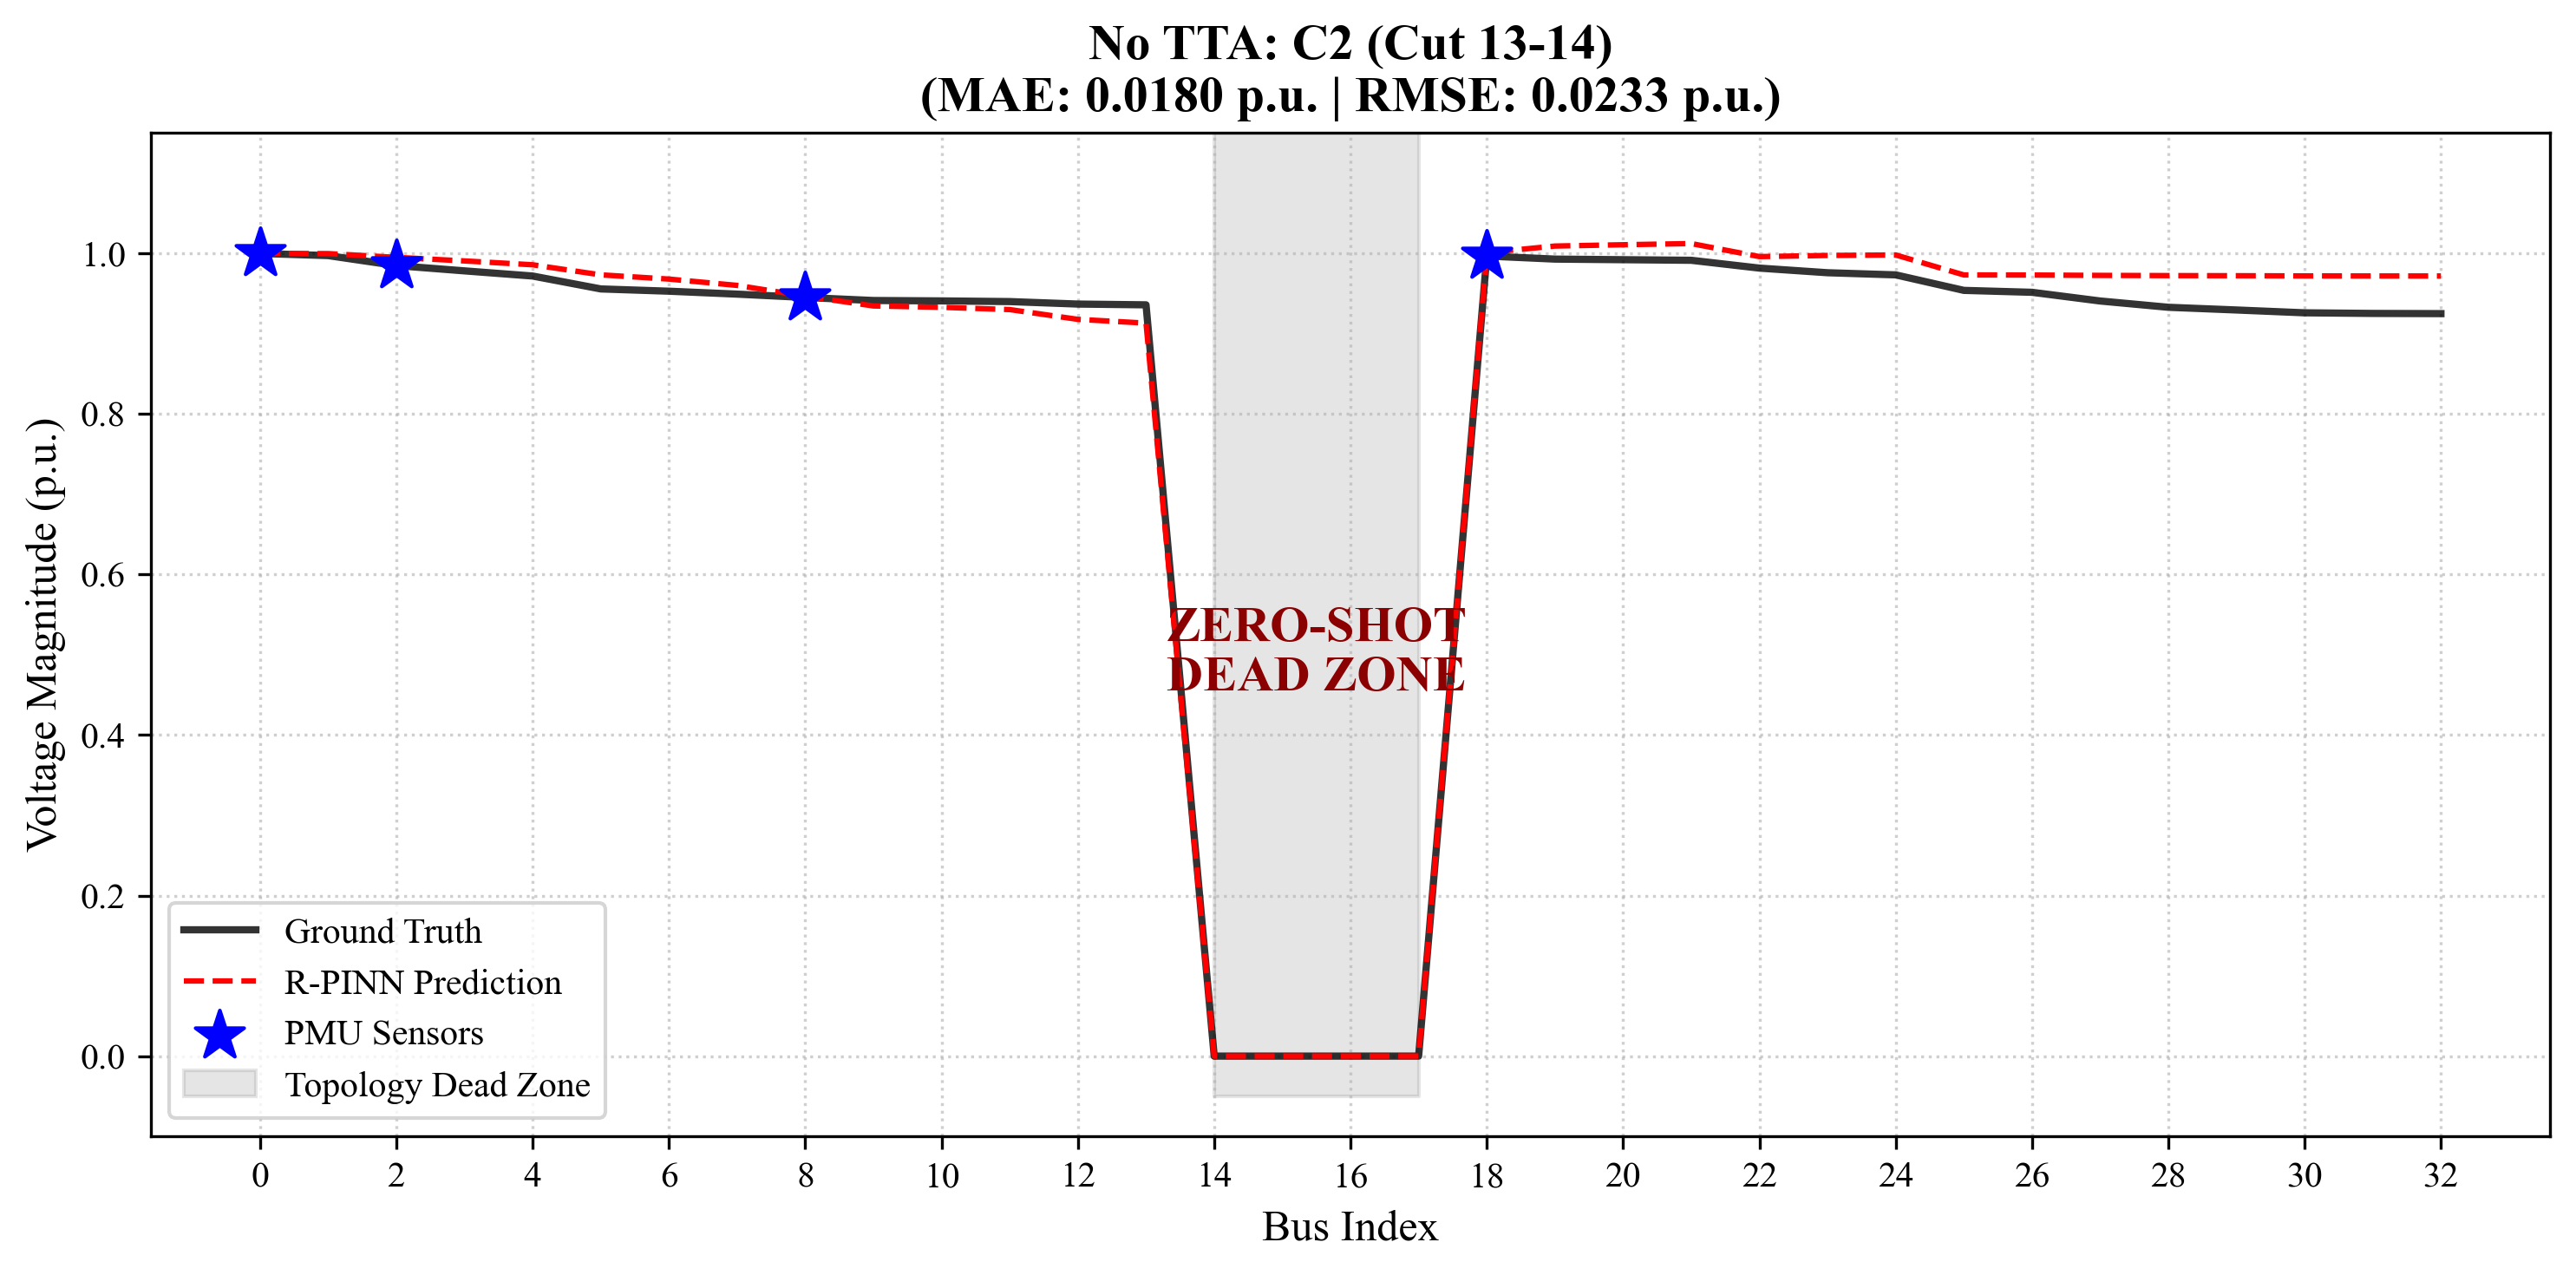


🔬 [NO TTA] 场景: C3 (Cut 6-26)
   • MAE:  9.386422e-03 p.u. | RMSE: 1.289000e-02 p.u. | RSE: 1.527715e-02
   🚫 物理死区识别: 节点 [25 26 27 28 29 30 31 32]


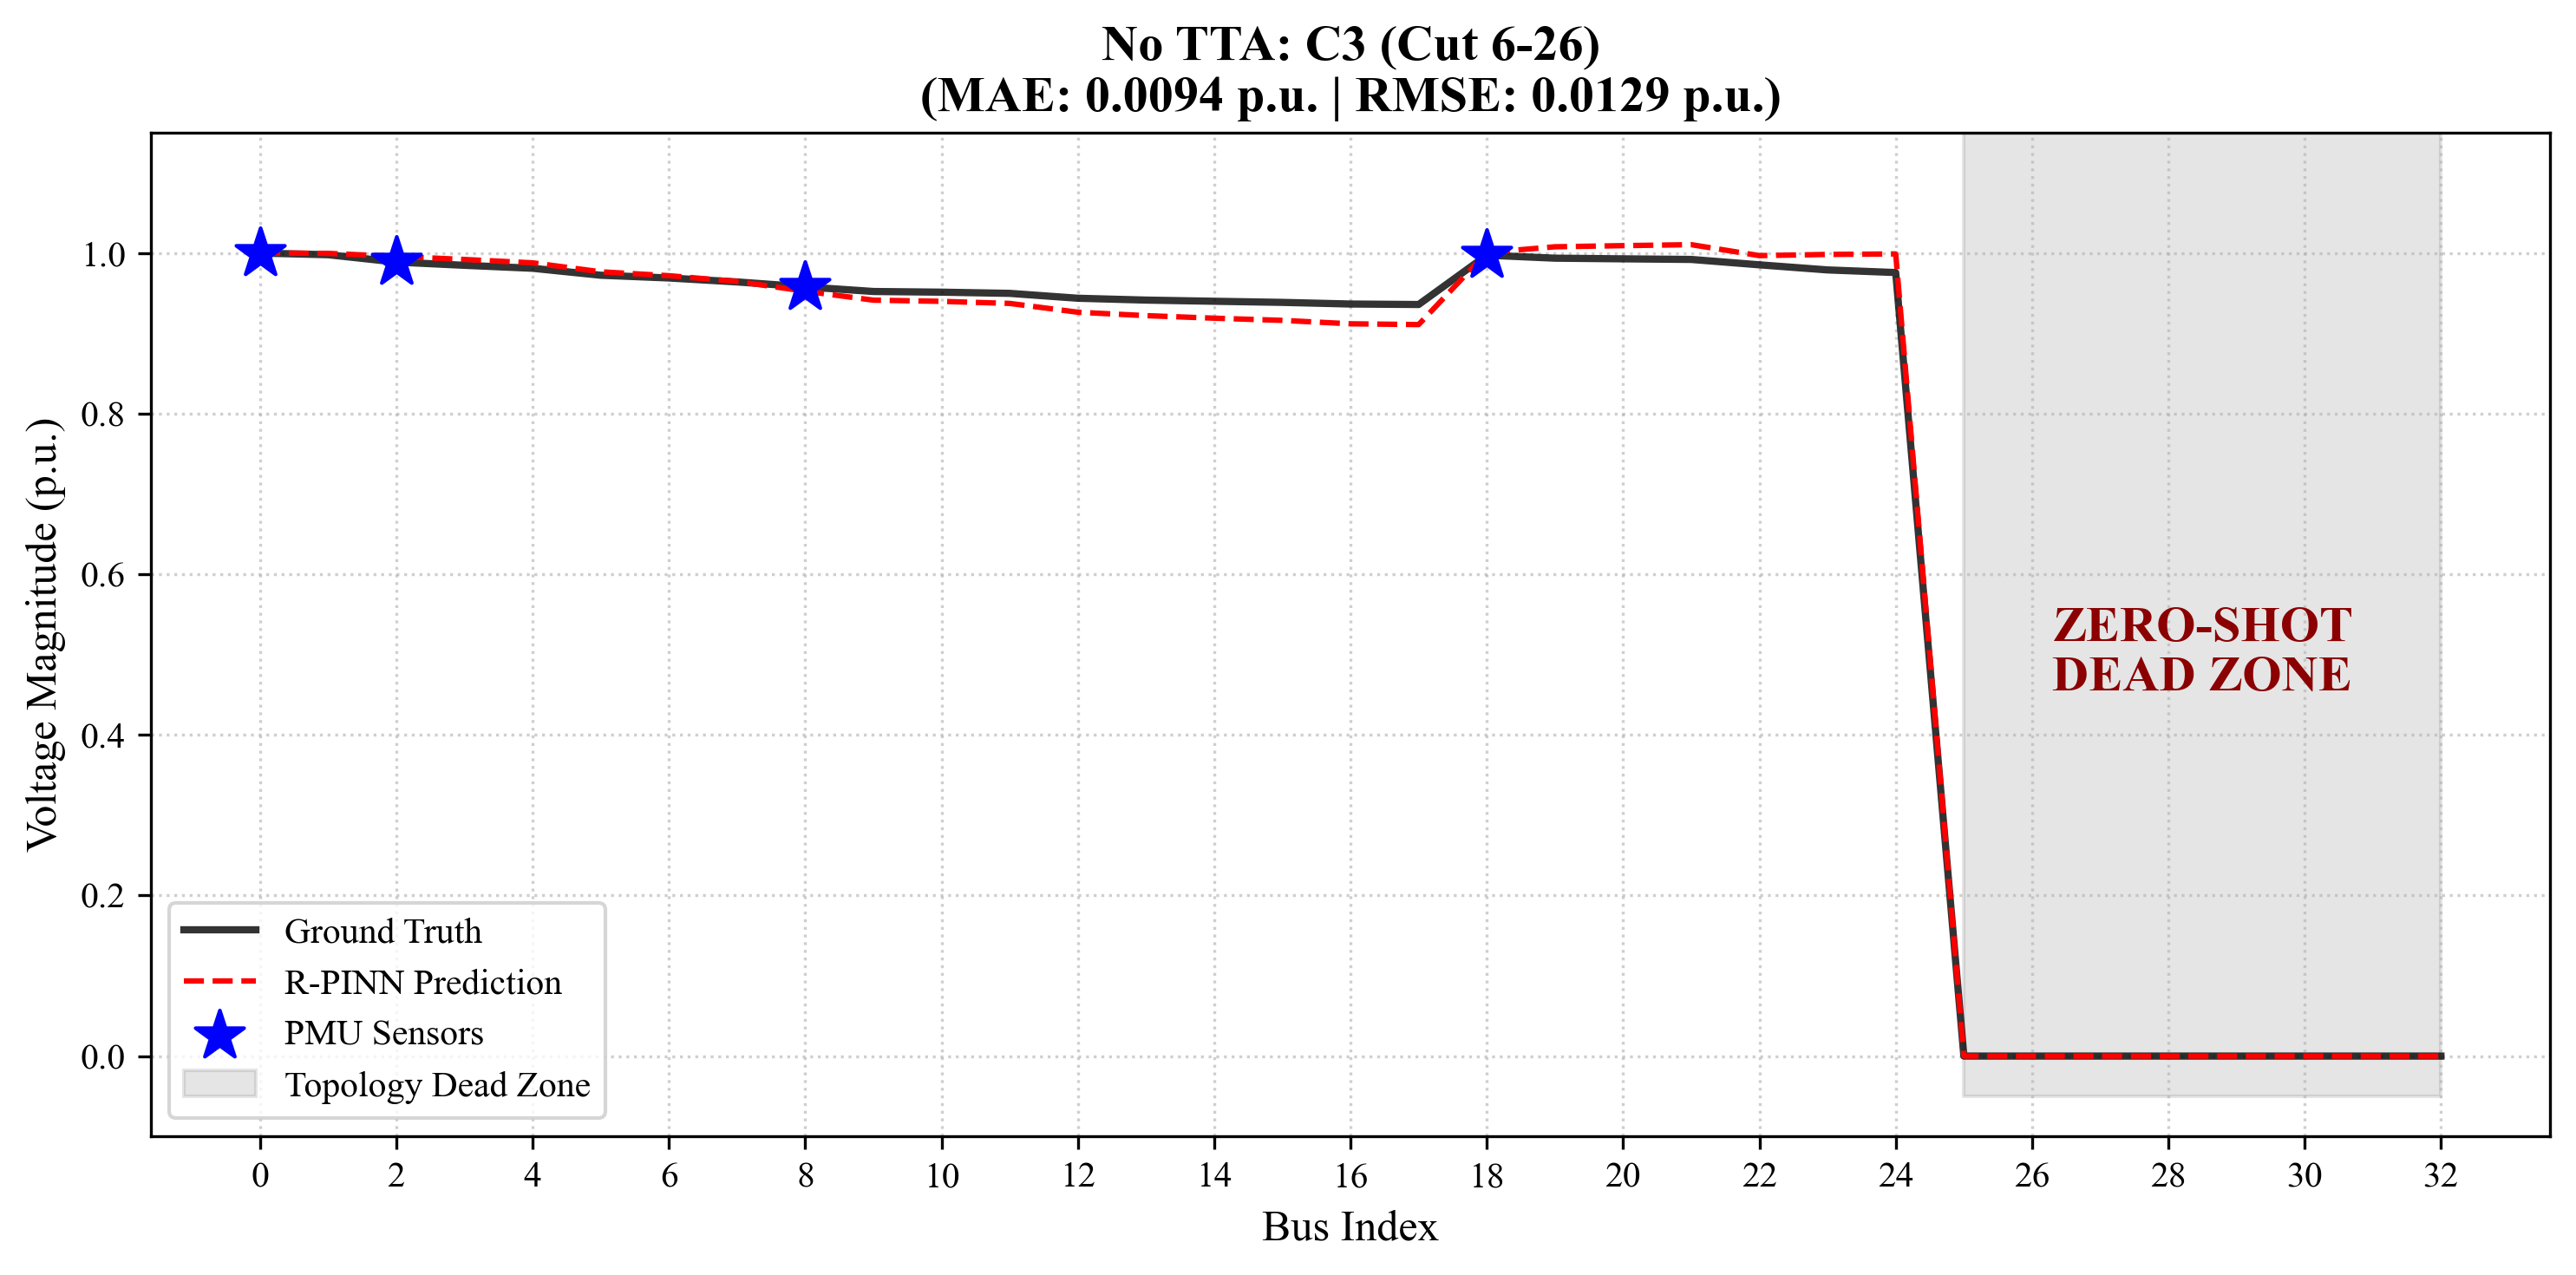


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
⚔️ Phase 2: 引入 Test-Time Adaptation (在线物理自适应)
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

⚡ 正在对 C1 (Cut 7-8) 进行在线物理重构 (20 轮 TTA)...
🔬 [TTA 增强] 场景: C1 (Cut 7-8)
   • MAE:  1.337112e-02 p.u. | RMSE: 1.963824e-02 p.u. | RSE: 2.428941e-02
   🚫 物理死区完美隔离: 节点 [ 8  9 10 11 12 13 14 15 16 17]


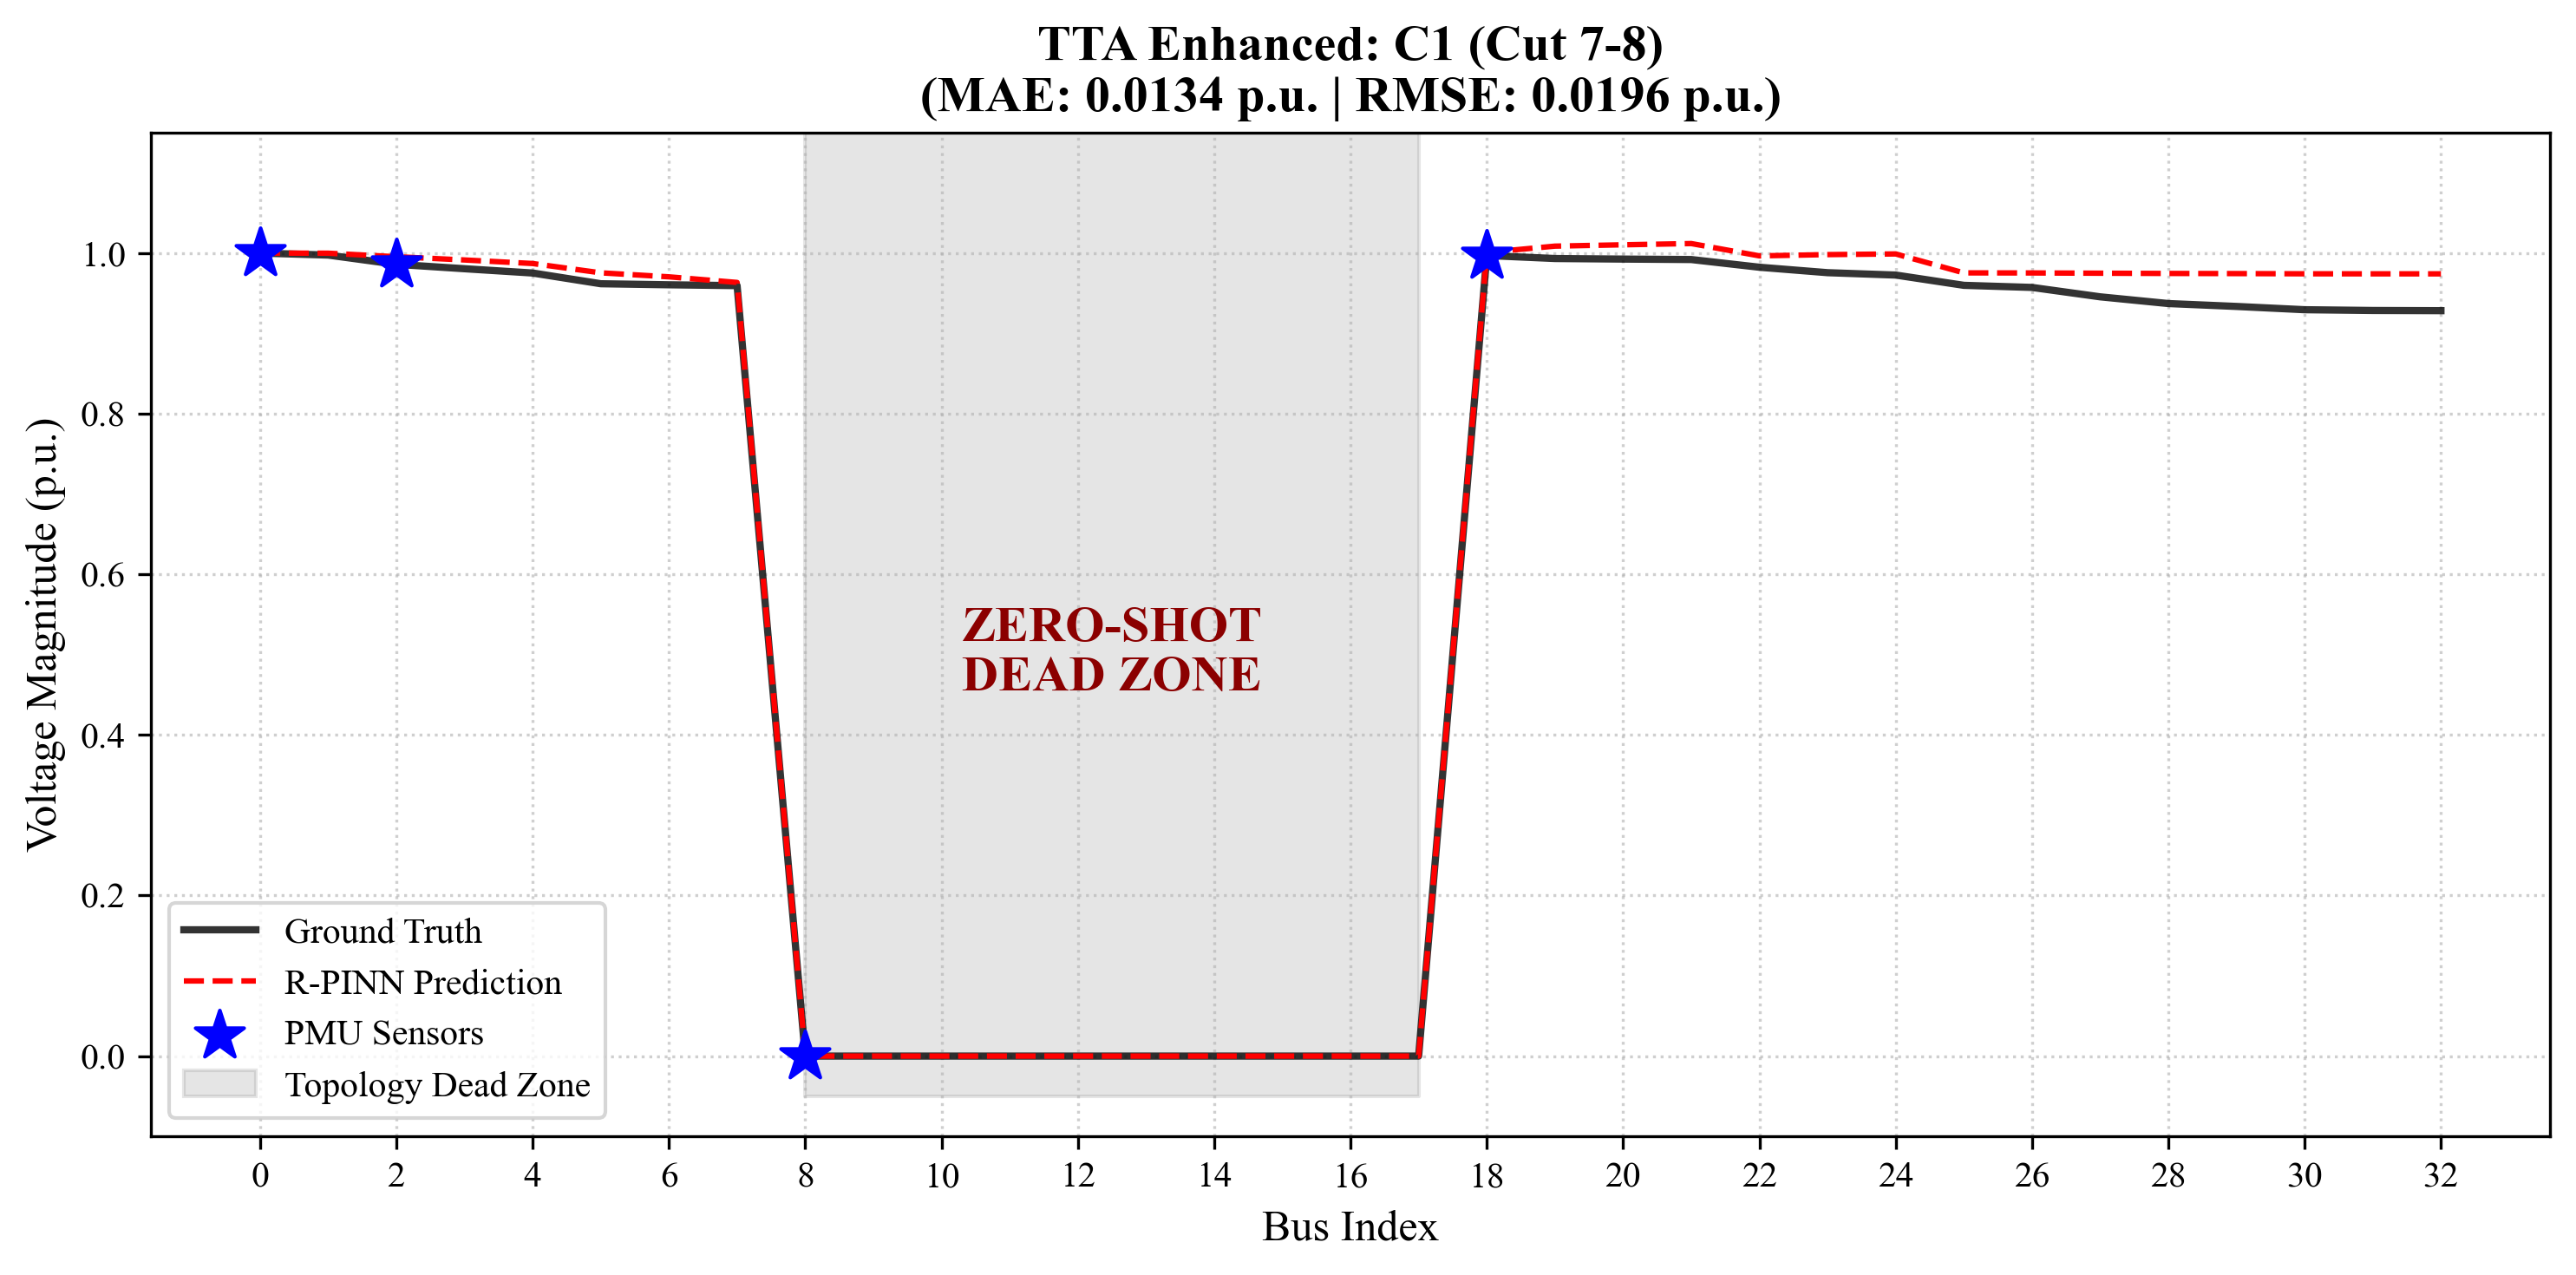


⚡ 正在对 C2 (Cut 13-14) 进行在线物理重构 (20 轮 TTA)...
🔬 [TTA 增强] 场景: C2 (Cut 13-14)
   • MAE:  1.755724e-02 p.u. | RMSE: 2.277908e-02 p.u. | RSE: 2.534381e-02
   🚫 物理死区完美隔离: 节点 [14 15 16 17]


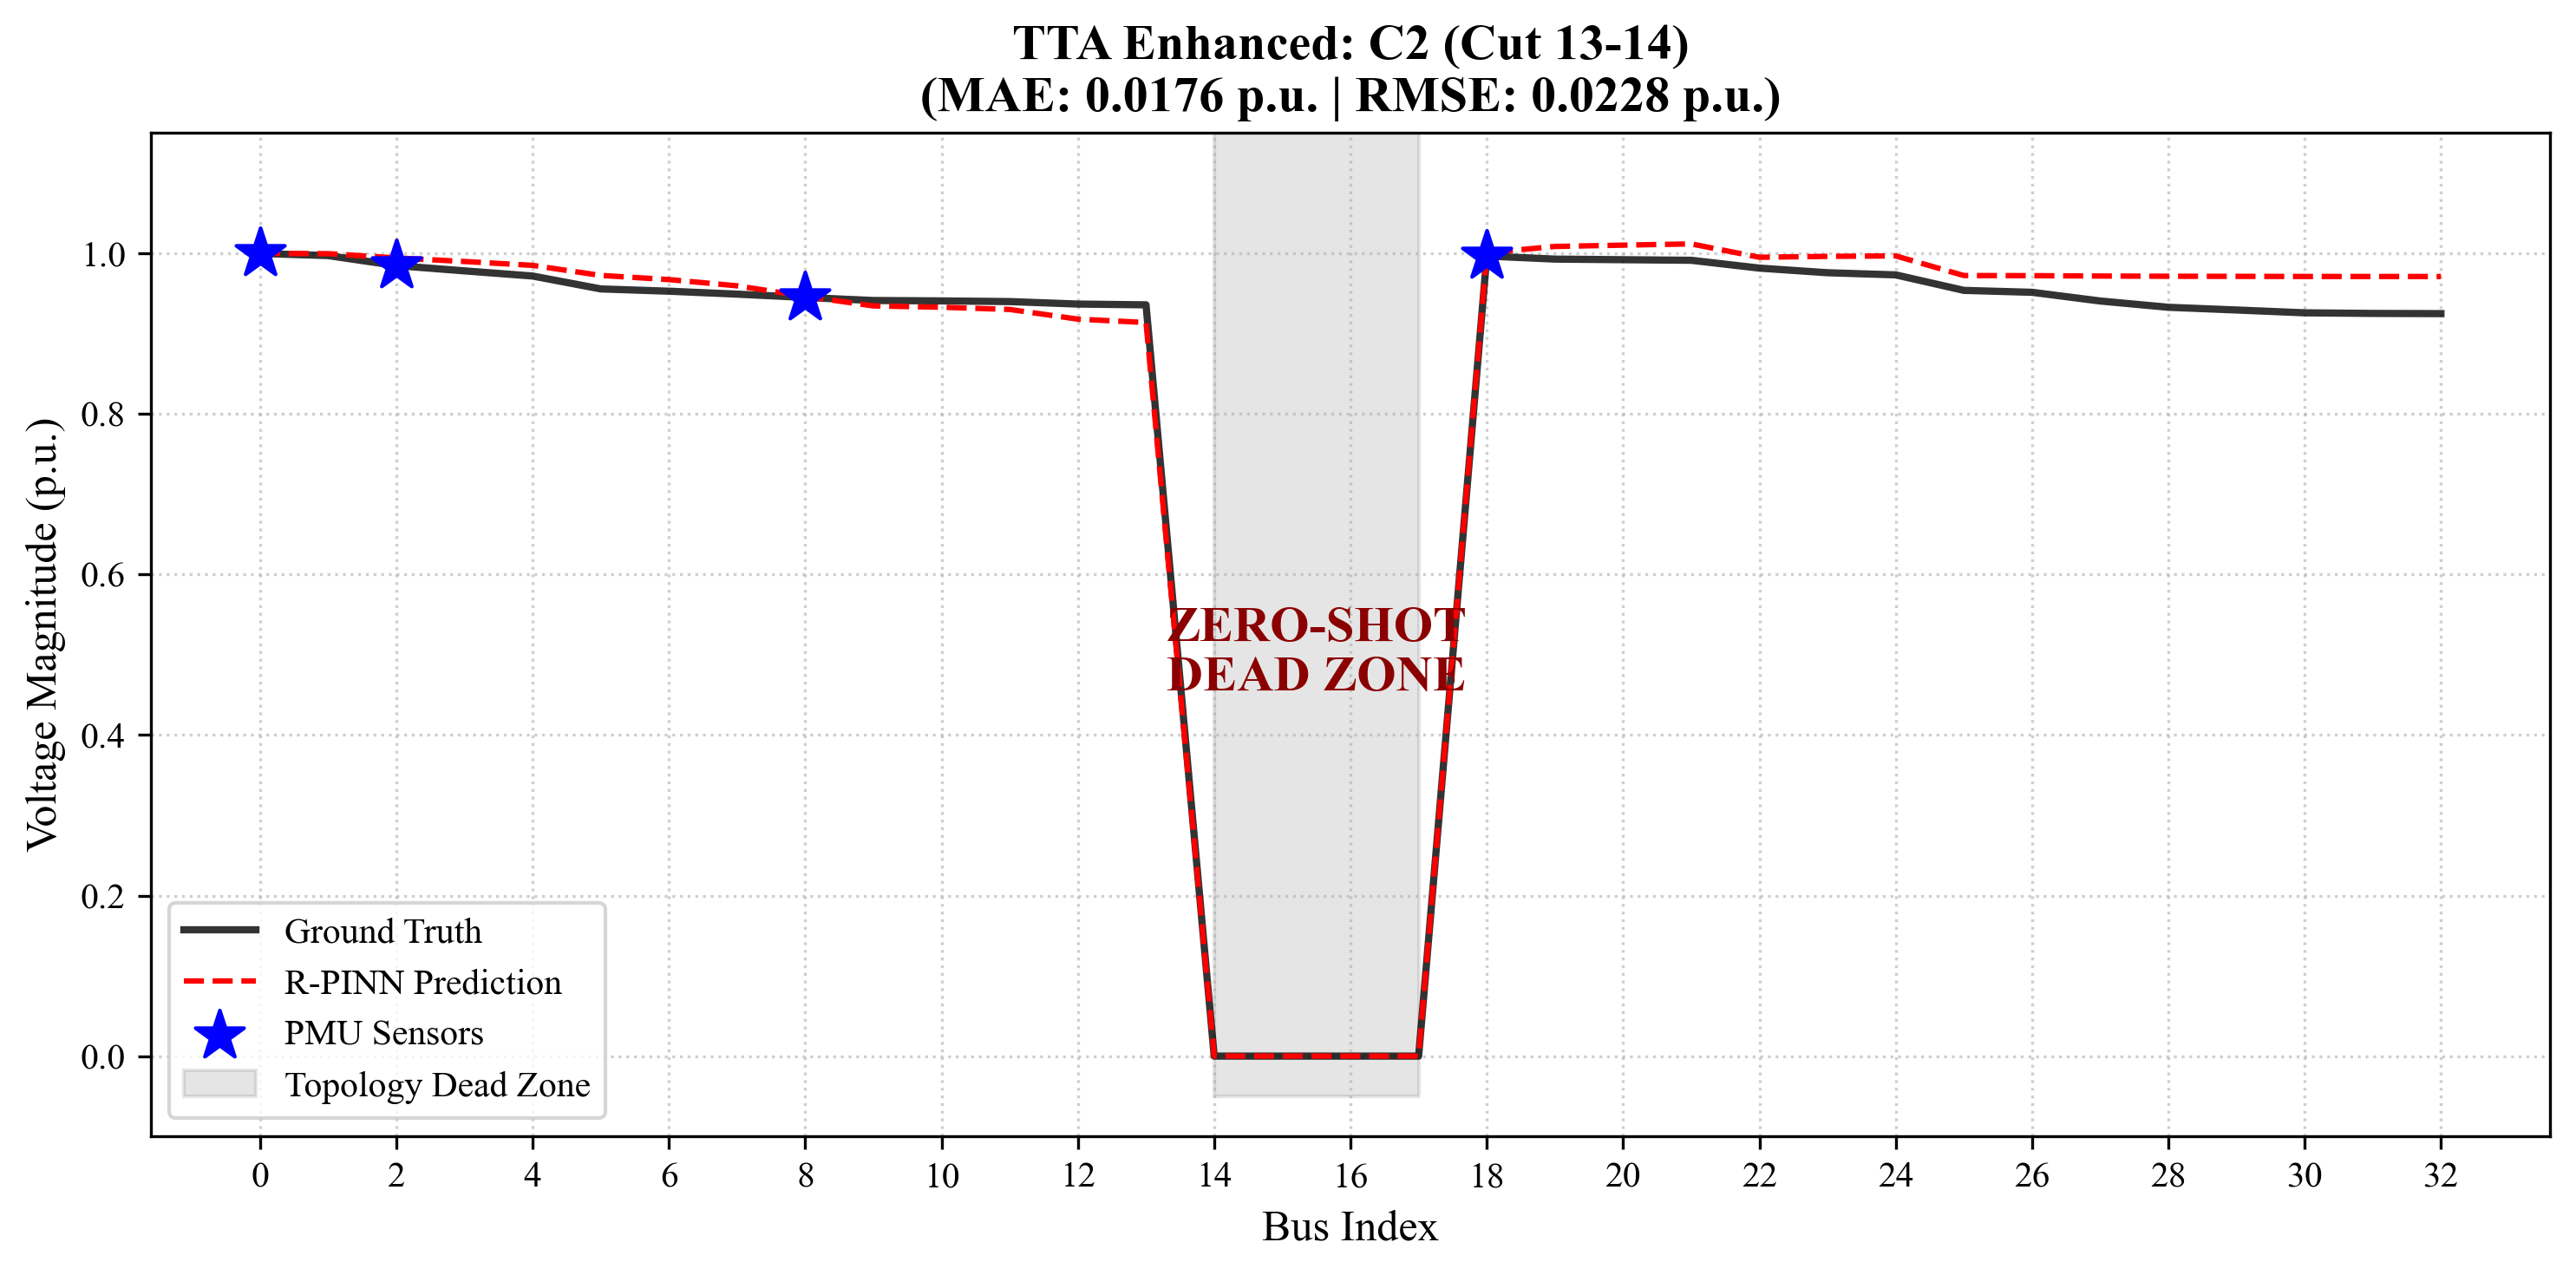


⚡ 正在对 C3 (Cut 6-26) 进行在线物理重构 (20 轮 TTA)...
🔬 [TTA 增强] 场景: C3 (Cut 6-26)
   • MAE:  8.662976e-03 p.u. | RMSE: 1.180919e-02 p.u. | RSE: 1.399619e-02
   🚫 物理死区完美隔离: 节点 [25 26 27 28 29 30 31 32]


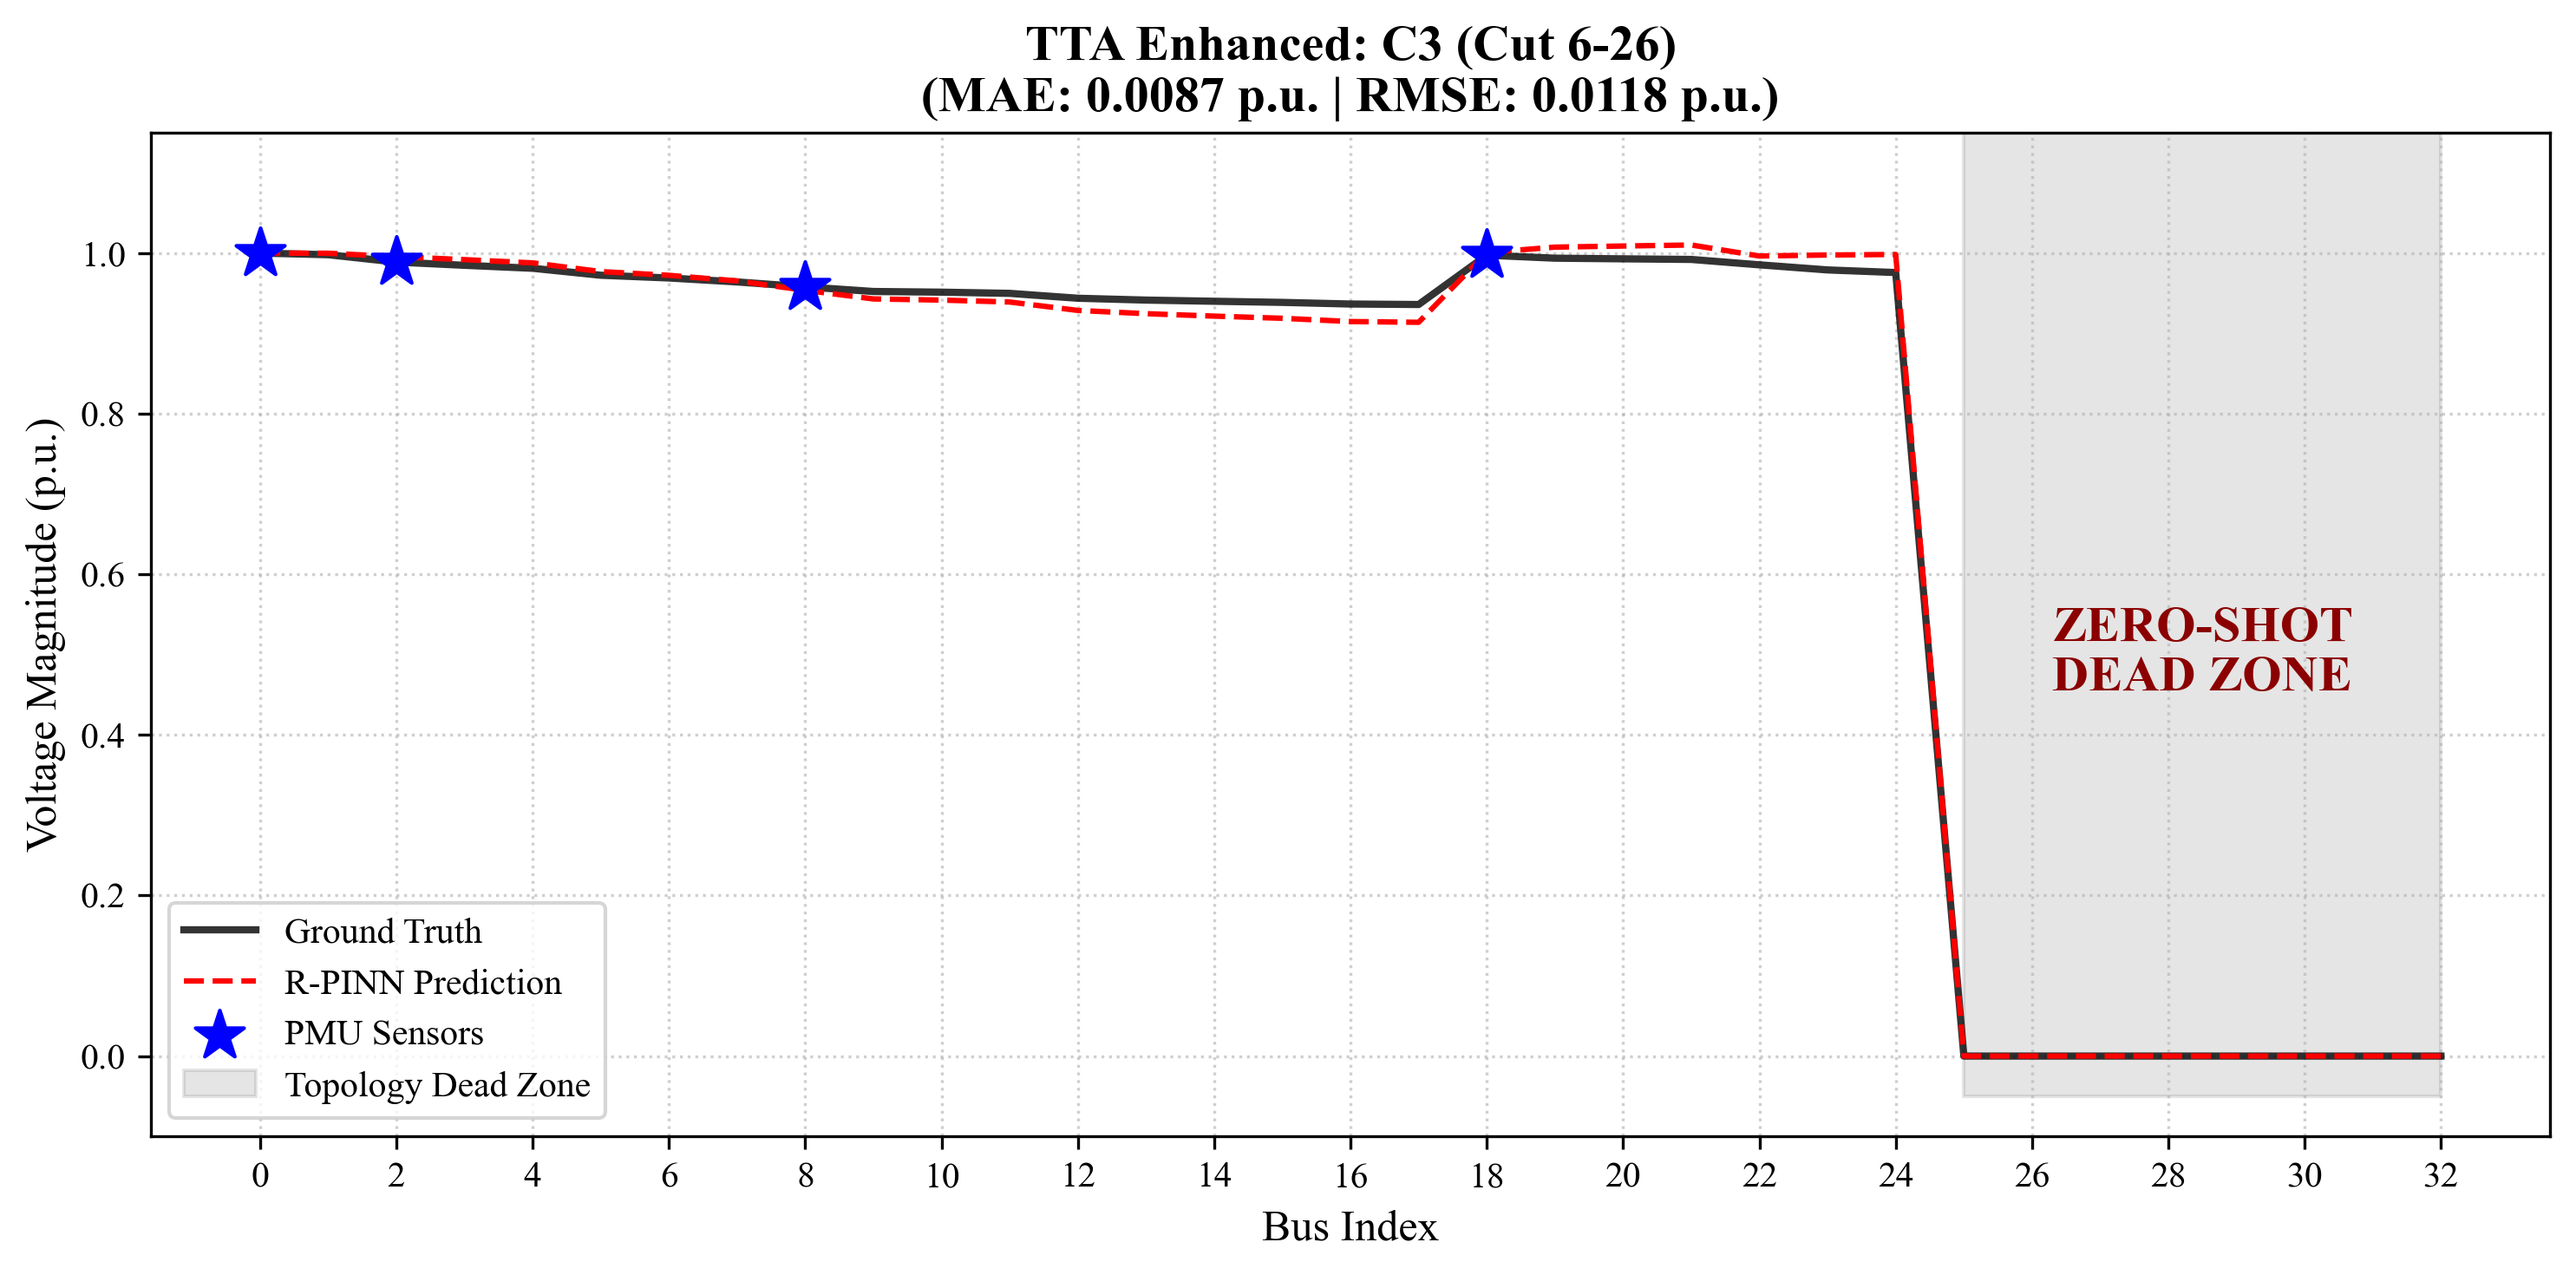

In [3]:
# ==============================================================================
# [IEEE Transactions 终极满血版] R-PINN 33节点：基态 -> Zero-shot -> TTA
# 绝杀修复：独立 Mean-Loss 封装，256宽灵巧网络防过拟合，余弦退火学习率
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
from collections import deque
import copy
import matplotlib.pyplot as plt

# --- 绘图风格设置 (学术顶刊质感) ---
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ------------------------------------------
# 🔒 1. 核心控制台：锁定随机性与配置
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_obs_indices(num_nodes=33, seed=42):
    random.seed(seed)  
    num_obs = int(num_nodes * 0.15)  # 15% 极限盲区
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_obs_indices = get_obs_indices(33, 42)

print("="*65)
print(f"🚀 炼丹炉就绪! 算力: {device}")
print(f"📡 锁定的 15% PMU 观测点: {global_obs_indices}")
print("="*65)

# ------------------------------------------
# ⚡ 2. 物理环境构建：提取 33 节点导纳矩阵
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

def build_ybus(cut_f_0idx=None, cut_t_0idx=None):
    y_bus = np.zeros((33, 33), dtype=complex)
    for i in range(len(branch_data)):
        f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
        if cut_f_0idx is not None and cut_t_0idx is not None:
            if (f == cut_f_0idx and t == cut_t_0idx) or (f == cut_t_0idx and t == cut_f_0idx):
                continue
        y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
        y_bus[f, f] += y_line
        y_bus[t, t] += y_line
        y_bus[f, t] = y_bus[t, f] = -y_line
    return torch.tensor(y_bus.real, dtype=torch.float32).to(device), torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

G_tensor, B_tensor = build_ybus()

# ------------------------------------------
# 🧠 3. 核心引擎：256灵巧网络与独立 Mean Loss
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]
        masked_x[:, idx + 33] = batch_x[:, idx + 33]
    return masked_x

def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    dT = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

def compute_loss_components(V_pred, theta_pred, P_real, Q_real, V_real, G, B, obs_idx):
    P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, G, B)
    
    P_loss = torch.mean((P_calc - P_real) ** 2)
    Q_loss = torch.mean((Q_calc - Q_real) ** 2)
    
    V_obs_pred, V_obs_real = V_pred[:, obs_idx], V_real[:, obs_idx]
    obs_loss = torch.mean((V_obs_pred - V_obs_real) ** 2)
    
    penalty_low = torch.nn.functional.relu(0.85 - V_pred)
    penalty_high = torch.nn.functional.relu(V_pred - 1.10)
    penalty_loss = torch.mean(penalty_low + penalty_high)
    
    return P_loss, Q_loss, obs_loss, penalty_loss

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN, self).__init__()
        # 🚀 绝杀修复 1：网络瘦身，换回 256 灵巧外骨骼，防止灾难性过拟合
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU()
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)
        
        # 👑【核心创新点】：ARS非对称残差缩放
        Vm_pred = 1.0 + 0.1 * output[:, :33]    
        theta_pred = 0.0 + 0.1 * output[:, 33:] 
        
        # 硬锚定
        Vm_pred_clone = Vm_pred.clone(); theta_pred_clone = theta_pred.clone()
        Vm_pred_clone[:, 0] = 1.0; theta_pred_clone[:, 0] = 0.0 
        return Vm_pred_clone, theta_pred_clone

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx

    def forward(self, V_pred, theta_pred, P_real_target, Q_real_target, V_real, p_weight, obs_weight=100000):
        P_loss, Q_loss, obs_loss, penalty_loss = compute_loss_components(
            V_pred, theta_pred, P_real_target, Q_real_target, V_real, self.G, self.B, self.obs_idx
        )
        
        # 🚀 绝杀修复 2：给 penalty 松绑，权重从 1000 降到 100，释放物理 Loss 的枷锁
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 100 * penalty_loss

class MyDataset(Dataset):
    def __init__(self, features, labels): self.features, self.labels = features, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

# ------------------------------------------
# 📥 4. 数据装载
# ------------------------------------------
print("📥 正在读取 50,000 条 33 节点物理样本...")
df = pd.read_csv(r'IEEE33_50000_Safe_Final.csv').fillna(0.0)
raw_data = df.values.reshape(-1, 33, 4)

P_real_pu = raw_data[:, :, 0] / 100.0  
Q_real_pu = raw_data[:, :, 1] / 100.0
V_real_pu = raw_data[:, :, 2]

ssl = StandardScaler()
X_norm = ssl.fit_transform(raw_data[:, :, 0:2].reshape(-1, 66))

mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
PQV_target_tensor = torch.tensor(np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1), dtype=torch.float32).to(device)
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(MyDataset(X_tensor, PQV_target_tensor), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 🗡️ [战役一]：基态深度训练 (逼近稳态极限) -> 🌟 已替换为 0.021 神级配置 🌟
# ==============================================================================
model = PowerGridPINN(input_dim=66).to(device)

# 🌟 物理先验锚定
with torch.no_grad():
    model.output_layers.bias[:33].fill_(-0.5)

pinn_loss = PowerPINNLoss(G_tensor, B_tensor, global_obs_indices)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 🌟 绝杀修复：抛弃余弦退火，换成 Cell 7 里立大功的 StepLR！
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

# 🌟 绝杀修复：把 epoch 砍到和鲁棒性测试一样的 150 轮！
max_epoch = 150 
print("\n🔥 启动基态深度训练 (对齐鲁棒性配置 150 轮)...")

for epoch in range(max_epoch):
    # 🌟 物理权重提振时机对齐 Cell 7：前 50 轮 1000，之后 5000
    p_weight = 1000 if epoch < 50 else 5000
    model.train()
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, global_obs_indices, mean_tensor, scale_tensor)
        
        V_guess, theta_guess = model(mask_x)
        
        # 🌟 观测权重死死咬住 2500000
        loss = pinn_loss(V_guess, theta_guess, real_p, real_q, real_v, p_weight, obs_weight=2500000)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    if epoch % 30 == 0 or epoch == max_epoch - 1:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer.param_groups[0]['lr']:.6e}")

model.eval()
with torch.no_grad():
    pred_Vm_tensor, _ = model(apply_blind_zone(X_tensor[:1000], global_obs_indices, mean_tensor, scale_tensor))
    error = pred_Vm_tensor.cpu().numpy() - V_real_pu[:1000]
    mae_base = np.mean(np.abs(error))
    rmse_base = np.sqrt(np.mean(error**2))

print("\n" + "="*65)
print(f"🏆 [基态验收 终极对账] Overall MAE: {mae_base:.6e} p.u. | RMSE: {rmse_base:.6e} p.u.")
print("="*65)

# ------------------------------------------
# 🔧 辅助工具箱：拓扑识别、指标计算、出图
# ------------------------------------------
def get_topology_mask(G_np, B_np, num_nodes=33, root=0):
    mask = np.zeros(num_nodes, dtype=np.float32)
    adj = (np.abs(G_np) > 1e-6) | (np.abs(B_np) > 1e-6)
    q = deque([root]); mask[root] = 1.0 
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0: mask[v] = 1.0; q.append(v)
    return torch.tensor(mask, dtype=torch.float32).to(device)

def calculate_safe_metrics(v_pred, v_true):
    eps = 1e-12
    err = v_pred - v_true
    mae = torch.mean(torch.abs(err)).item()
    rmse = torch.sqrt(torch.mean(err**2)).item()
    rmae = (torch.sum(torch.abs(err)) / (torch.sum(torch.abs(v_true)) + eps)).item()
    rse = (torch.sqrt(torch.sum(err**2)) / (torch.sqrt(torch.sum(v_true**2)) + eps)).item()
    return mae, rmse, rmae, rse

def plot_academic_case(nodes, v_true, v_pred, pmu_idx, mask, title, mae_val, rmse_val):
    plt.figure(figsize=(10, 5))
    plt.plot(nodes, v_true, 'k-', label='Ground Truth', linewidth=2, alpha=0.8)
    plt.plot(nodes, v_pred, 'r--', label='R-PINN Prediction', linewidth=1.5)
    plt.scatter(pmu_idx, v_true[pmu_idx], color='blue', marker='*', s=200, label='PMU Sensors', zorder=5)
    
    dead_nodes = np.where(mask == 0)[0]
    if len(dead_nodes) > 0:
        plt.fill_between(dead_nodes, -0.05, 1.15, color='gray', alpha=0.2, label='Topology Dead Zone')
        plt.text(np.mean(dead_nodes), 0.5, 'ZERO-SHOT\nDEAD ZONE', color='darkred', 
                 fontsize=14, fontweight='bold', ha='center', va='center')

    plt.title(f"{title}\n(MAE: {mae_val:.4f} p.u. | RMSE: {rmse_val:.4f} p.u.)", fontsize=14, fontweight='bold')
    plt.xlabel('Bus Index', fontsize=12)
    plt.ylabel('Voltage Magnitude (p.u.)', fontsize=12)
    plt.ylim(-0.1, 1.15)
    plt.xticks(nodes[::2])
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left', fontsize=10)
    plt.tight_layout()
    plt.show()

test_cases = [
    {"n": "C1 (Cut 7-8)", "csv": "data_33_C1.csv", "cut": (7, 8)},
    {"n": "C2 (Cut 13-14)", "csv": "data_33_C2.csv", "cut": (13, 14)},
    {"n": "C3 (Cut 6-26)", "csv": "data_33_C3.csv", "cut": (5, 25)}
]
nodes = np.arange(33)

# ==============================================================================
# 🛡️ [战役二]：Zero-shot 零样本直突 
# ==============================================================================
print("\n" + "🔥" * 25)
print("🛡️ Phase 1: Zero-shot 零样本断线对账 (无 TTA)")
print("🔥" * 25)

with torch.no_grad():
    for case in test_cases:
        try:
            df_c = pd.read_csv(case["csv"]).fillna(0.0)
            raw_c = df_c.values.reshape(-1, 33, 4)
            X_c = torch.tensor(ssl.transform(raw_c[:,:,0:2].reshape(-1, 66)), dtype=torch.float32).to(device)
            V_t = torch.tensor(raw_c[:,:,2], dtype=torch.float32).to(device)
            
            G_f, B_f = build_ybus(case["cut"][0], case["cut"][1])
            mask_t = get_topology_mask(G_f.cpu().numpy(), B_f.cpu().numpy())
            
            V_raw, _ = model(apply_blind_zone(X_c, global_obs_indices, mean_tensor, scale_tensor))
            V_final = V_raw * mask_t
            
            mae, rmse, rmae, rse = calculate_safe_metrics(V_final, V_t * mask_t)
            print(f"\n🔬 [NO TTA] 场景: {case['n']}")
            print(f"   • MAE:  {mae:.6e} p.u. | RMSE: {rmse:.6e} p.u. | RSE: {rse:.6e}")
            print(f"   🚫 物理死区识别: 节点 {torch.where(mask_t == 0)[0].cpu().numpy()}")
            
            plot_academic_case(nodes, (V_t[0] * mask_t).cpu().numpy(), V_final[0].cpu().numpy(), 
                               global_obs_indices, mask_t.cpu().numpy(), f"No TTA: {case['n']}", mae, rmse)
        except Exception as e:
            print(f"❌ 运行故障 ({case['n']}): {e}")

# ==============================================================================
# ⚔️ [战役三]：在线物理自适应 TTA 
# ==============================================================================
print("\n" + "🔥" * 25)
print("⚔️ Phase 2: 引入 Test-Time Adaptation (在线物理自适应)")
print("🔥" * 25)

for case in test_cases:
    try:
        df_c = pd.read_csv(case["csv"]).fillna(0.0)
        raw_c = df_c.values.reshape(-1, 33, 4)
        X_c = torch.tensor(ssl.transform(raw_c[:,:,0:2].reshape(-1, 66)), dtype=torch.float32).to(device)
        V_t = torch.tensor(raw_c[:,:,2], dtype=torch.float32).to(device)
        
        G_f, B_f = build_ybus(case["cut"][0], case["cut"][1])
        mask_t = get_topology_mask(G_f.cpu().numpy(), B_f.cpu().numpy())
        
        model_tta = copy.deepcopy(model)
        model_tta.train() 
        pinn_loss_tta = PowerPINNLoss(G_f, B_f, global_obs_indices)
        
        # 🚀 绝杀修复 3：TTA 学习率暴降到 1e-5，防止四点绑架
        optimizer_tta = torch.optim.Adam(model_tta.parameters(), lr=1e-5) 
        
        print(f"\n⚡ 正在对 {case['n']} 进行在线物理重构 (20 轮 TTA)...")
        masked_x_tta = apply_blind_zone(X_c[0:1], global_obs_indices, mean_tensor, scale_tensor)
        
        # 🚀 绝杀修复 4：见好就收，轮数砍到 20 轮
        for tta_epoch in range(20):
            optimizer_tta.zero_grad()
            V_guess, theta_guess = model_tta(masked_x_tta)
            
            P_zero = torch.zeros_like(V_guess).to(device)
            Q_zero = torch.zeros_like(V_guess).to(device)
            
            loss = pinn_loss_tta(V_guess, theta_guess, P_zero, Q_zero, V_t[0:1], p_weight=5000, obs_weight=10000000)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tta.parameters(), max_norm=1.0)
            optimizer_tta.step()
        
        model_tta.eval()
        with torch.no_grad():
            V_raw, _ = model_tta(apply_blind_zone(X_c, global_obs_indices, mean_tensor, scale_tensor))
            V_final = V_raw * mask_t
            
            mae, rmse, rmae, rse = calculate_safe_metrics(V_final, V_t * mask_t)
            
            print(f"🔬 [TTA 增强] 场景: {case['n']}")
            print(f"   • MAE:  {mae:.6e} p.u. | RMSE: {rmse:.6e} p.u. | RSE: {rse:.6e}")
            print(f"   🚫 物理死区完美隔离: 节点 {torch.where(mask_t == 0)[0].cpu().numpy()}")
            
            plot_academic_case(nodes, (V_t[0] * mask_t).cpu().numpy(), V_final[0].cpu().numpy(), 
                               global_obs_indices, mask_t.cpu().numpy(), f"TTA Enhanced: {case['n']}", mae, rmse)

    except Exception as e:
        print(f"❌ TTA 运行故障 ({case['n']}): {e}")

In [5]:
# ==============================================================================
# [Sum-Loss 消融实验终极版] R-PINN 训练脚本 (命名: model1)
# 核心消融逻辑：观测误差 (Obs Loss) 强制使用 SUM 聚合
# 严谨对账：已对齐 150轮 + StepLR 黄金配置，确保与主方法起跑线百分之百一致！
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
from collections import deque
import matplotlib.pyplot as plt

# --- 绘图风格设置 (学术顶刊质感) ---
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ------------------------------------------
# 🔒 1. 核心控制台
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_obs_indices(num_nodes=33, seed=42):
    random.seed(seed); num_obs = int(num_nodes * 0.15)
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

set_seed(42)
global_obs_indices = get_obs_indices(33, 42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------
# ⚡ 2. 物理环境构建 (导纳矩阵)
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

def build_ybus(cut_f_0idx=None, cut_t_0idx=None):
    y_bus = np.zeros((33, 33), dtype=complex)
    for i in range(len(branch_data)):
        f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
        if cut_f_0idx is not None and cut_t_0idx is not None:
            if (f == cut_f_0idx and t == cut_t_0idx) or (f == cut_t_0idx and t == cut_f_0idx): continue
        y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
        y_bus[f, f] += y_line; y_bus[t, t] += y_line
        y_bus[f, t] = y_bus[t, f] = -y_line
    return torch.tensor(y_bus.real, dtype=torch.float32).to(device), torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

G_tensor, B_tensor = build_ybus()

# ------------------------------------------
# 🧠 3. 核心引擎：ARS 网络与 Sum-Loss 封装
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    p_zero_std = (0.0 - mean_t) / scale_t
    masked_x = p_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]; masked_x[:, idx + 33] = batch_x[:, idx + 33]
    return masked_x

def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    dT = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

def compute_loss_components_sum(V_pred, theta_pred, P_real, Q_real, V_real, G, B, obs_idx):
    P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, G, B)
    P_loss, Q_loss = torch.mean((P_calc - P_real) ** 2), torch.mean((Q_calc - Q_real) ** 2)
    V_obs_pred, V_obs_real = V_pred[:, obs_idx], V_real[:, obs_idx]
    # 👑 消融实验核心：保持 SUM
    obs_loss = torch.sum((V_obs_pred - V_obs_real) ** 2)
    penalty = torch.mean(torch.nn.functional.relu(0.85 - V_pred) + torch.nn.functional.relu(V_pred - 1.10))
    return P_loss, Q_loss, obs_loss, penalty

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU()
        )
        self.output_layers = nn.Linear(256, 66)
    def forward(self, x):
        features = self.hidden_layers(x); output = self.output_layers(features)
        Vm_pred = 1.0 + 0.1 * output[:, :33]; theta_pred = 0.0 + 0.1 * output[:, 33:]
        Vm_pred_c, theta_pred_c = Vm_pred.clone(), theta_pred.clone()
        Vm_pred_c[:, 0], theta_pred_c[:, 0] = 1.0, 0.0
        return Vm_pred_c, theta_pred_c

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
    def forward(self, V_pred, theta_pred, P_real_target, Q_real_target, V_real, p_weight, obs_weight=500000):
        P_loss, Q_loss, obs_loss, penalty_loss = compute_loss_components_sum(
            V_pred, theta_pred, P_real_target, Q_real_target, V_real, self.G, self.B, self.obs_idx
        )
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 100 * penalty_loss

# ------------------------------------------
# 📥 4. 数据装载 (50k 样本)
# ------------------------------------------
print("📥 正在读取 50,000 条 33 节点物理样本...")
df = pd.read_csv(r'IEEE33_50000_Safe_Final.csv').fillna(0.0)
raw_data = df.values.reshape(-1, 33, 4)
P_real_pu, Q_real_pu, V_real_pu = raw_data[:, :, 0] / 100.0, raw_data[:, :, 1] / 100.0, raw_data[:, :, 2]
ssl = StandardScaler(); X_norm = ssl.fit_transform(raw_data[:, :, 0:2].reshape(-1, 66))
mean_tensor, scale_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device), torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
PQV_target_tensor = torch.tensor(np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1), dtype=torch.float32).to(device)
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(list(zip(X_tensor, PQV_target_tensor)), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 🚀 5. model1 深度训练 (已同步黄金配置：150轮 + StepLR)
# ==============================================================================
model1 = PowerGridPINN(input_dim=66).to(device)

with torch.no_grad():
    model1.output_layers.bias[:33].fill_(-0.5)

pinn_loss = PowerPINNLoss(G_tensor, B_tensor, global_obs_indices)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)

# 🌟 黄金策略 1：StepLR
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

# 🌟 黄金策略 2：150 轮
max_epoch = 150 
print(f"🔥 启动 model1 深度训练 (Sum-Loss Strategy + 150轮对齐)...")

for epoch in range(max_epoch):
    # 🌟 黄金策略 3：物理权重提振时机对齐
    p_weight = 1000 if epoch < 50 else 5000
    model1.train(); running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, global_obs_indices, mean_tensor, scale_tensor)
        V_guess, theta_guess = model1(mask_x)
        # 🌟 绝对公平权重：500,000
        loss = pinn_loss(V_guess, theta_guess, real_p, real_q, real_v, p_weight, obs_weight=500000)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model1.parameters(), 1.0); optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 30 == 0 or epoch == max_epoch - 1:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer.param_groups[0]['lr']:.6e}")

model1.eval()
with torch.no_grad():
    pred_Vm_tensor, _ = model1(apply_blind_zone(X_tensor[:1000], global_obs_indices, mean_tensor, scale_tensor))
    error = pred_Vm_tensor.cpu().numpy() - V_real_pu[:1000]
    mae_base, rmse_base = np.mean(np.abs(error)), np.sqrt(np.mean(error**2))

print("\n" + "="*65)
print(f"🏆 [model1 对账单] 基态性能 (Sum-Loss + 黄金策略对齐)")
print(f"🌍 MAE:  {mae_base:.6e} p.u. | ⚡ RMSE: {rmse_base:.6e} p.u.")
print("="*65)

# --- 🌪️ N-1 故障测试模块保持不变 ---
# ==============================================================================
# 🌪️ 6. N-1 故障测试 (Zero-shot Inference Mode)
# ==============================================================================
print("\n🛡️ N-1 故障零样本测试 (Inference Mode)")

def get_topology_mask(G_np, B_np, num_nodes=33, root=0):
    mask = np.zeros(num_nodes, dtype=np.float32)
    adj = (np.abs(G_np) > 1e-6) | (np.abs(B_np) > 1e-6)
    q = deque([root]); mask[root] = 1.0 
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0: mask[v] = 1.0; q.append(v)
    return torch.tensor(mask, dtype=torch.float32).to(device)

def calculate_safe_metrics(v_pred, v_true):
    err = v_pred - v_true
    mae = torch.mean(torch.abs(err)).item()
    rmse = torch.sqrt(torch.mean(err**2)).item()
    return mae, rmse

test_cases = [
    {"n": "C1 (斩断 7-8)",  "csv": "data_33_C1.csv", "cut": (7, 8)},
    {"n": "C2 (斩断 13-14)", "csv": "data_33_C2.csv", "cut": (13, 14)},
    {"n": "C3 (斩断 6-26)",  "csv": "data_33_C3.csv", "cut": (5, 25)}
]

with torch.no_grad():
    for case in test_cases:
        try:
            df_c = pd.read_csv(case["csv"]).fillna(0.0)
            raw_c = df_c.values.reshape(-1, 33, 4)
            X_c = torch.tensor(ssl.transform(raw_c[:,:,0:2].reshape(-1, 66)), dtype=torch.float32).to(device)
            V_t = torch.tensor(raw_c[:,:,2], dtype=torch.float32).to(device)
            
            G_f, B_f = build_ybus(case["cut"][0], case["cut"][1])
            mask_t = get_topology_mask(G_f.cpu().numpy(), B_f.cpu().numpy())
            
            V_raw, _ = model1(apply_blind_zone(X_c, global_obs_indices, mean_tensor, scale_tensor))
            V_final = V_raw * mask_t
            
            mae, rmse = calculate_safe_metrics(V_final, V_t * mask_t)
            print(f"\n🔬 诊断场景: {case['n']}")
            print(f"   • MAE:  {mae:.6e} p.u.")
            print(f"   • RMSE: {rmse:.6e} p.u.")
            print(f"   🚫 物理死区: {torch.where(mask_t == 0)[0].cpu().numpy()}")
        except Exception as e:
            print(f"❌ 运行故障: {e}")

📥 正在读取 50,000 条 33 节点物理样本...
🔥 启动 model1 深度训练 (Sum-Loss Strategy + 150轮对齐)...
Epoch 0   | Avg Loss: 47987.1389 | LR: 1.000000e-03
Epoch 30  | Avg Loss: 529.5805 | LR: 1.000000e-03
Epoch 60  | Avg Loss: 1796.9741 | LR: 5.000000e-04
Epoch 90  | Avg Loss: 1788.6655 | LR: 2.500000e-04
Epoch 120 | Avg Loss: 1787.2489 | LR: 1.250000e-04
Epoch 149 | Avg Loss: 1787.1951 | LR: 1.250000e-04

🏆 [model1 对账单] 基态性能 (Sum-Loss + 黄金策略对齐)
🌍 MAE:  3.067536e-03 p.u. | ⚡ RMSE: 4.223466e-03 p.u.

🛡️ N-1 故障零样本测试 (Inference Mode)

🔬 诊断场景: C1 (斩断 7-8)
   • MAE:  4.145402e-03 p.u.
   • RMSE: 6.149776e-03 p.u.
   🚫 物理死区: [ 8  9 10 11 12 13 14 15 16 17]

🔬 诊断场景: C2 (斩断 13-14)
   • MAE:  4.903935e-03 p.u.
   • RMSE: 6.795476e-03 p.u.
   🚫 物理死区: [14 15 16 17]

🔬 诊断场景: C3 (斩断 6-26)
   • MAE:  7.587451e-03 p.u.
   • RMSE: 1.013469e-02 p.u.
   🚫 物理死区: [25 26 27 28 29 30 31 32]


In [6]:
# ==============================================================================
# [消融对照版 - 绝对裸奔对账版] 33 节点 Vanilla PINN (无 ARS + Mean Loss)
# 核心消融：绝对移除 ARS 物理缩放！移除偏置初始化！
# 严谨对账：同步 150轮 + StepLR 黄金炼丹配置，与 Proposed 方案进行极限死斗！
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
from collections import deque
import copy
import matplotlib.pyplot as plt

# --- 绘图风格设置 ---
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ------------------------------------------
# 🔒 1. 核心控制台
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_obs_indices(num_nodes=33, seed=42):
    random.seed(seed); num_obs = int(num_nodes * 0.15)  
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_obs_indices = get_obs_indices(33, 42)

print("="*65)
print(f"🚀 Vanilla PINN 消融实验舱 (对齐版) 就绪! 算力: {device}")
print(f"📡 锁定的 15% PMU 观测点: {global_obs_indices}")
print("="*65)

# ------------------------------------------
# ⚡ 2. 物理环境构建
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

def build_ybus(cut_f_0idx=None, cut_t_0idx=None):
    y_bus = np.zeros((33, 33), dtype=complex)
    for i in range(len(branch_data)):
        f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
        if cut_f_0idx is not None and cut_t_0idx is not None:
            if (f == cut_f_0idx and t == cut_t_0idx) or (f == cut_t_0idx and t == cut_f_0idx): continue
        y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
        y_bus[f, f] += y_line; y_bus[t, t] += y_line
        y_bus[f, t] = y_bus[t, f] = -y_line
    return torch.tensor(y_bus.real, dtype=torch.float32).to(device), torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

G_tensor, B_tensor = build_ybus()

# ------------------------------------------
# 🧠 3. 核心引擎 (绝对裸奔：无 ARS，无偏置)
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]; masked_x[:, idx + 33] = batch_x[:, idx + 33]
    return masked_x

def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    dT = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

class VanillaPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(VanillaPINN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 66)
        )
    def forward(self, x):
        out = self.layers(x)
        # 👑 【消融核心】：绝对裸奔，不乘 0.1 也不加 1.0
        Vm_pred, theta_pred = out[:, :33], out[:, 33:]
        Vm_pred_c, theta_pred_c = Vm_pred.clone(), theta_pred.clone()
        Vm_pred_c[:, 0], theta_pred_c[:, 0] = 1.0, 0.0 
        return Vm_pred_c, theta_pred_c

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, p_weight, obs_weight=2500000):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        l_phys = self.mse(P_calc, P_real) + self.mse(Q_calc, Q_real)
        l_obs = self.mse(V_pred[:, self.obs_idx], V_real[:, self.obs_idx])
        l_pen = torch.mean(torch.nn.functional.relu(0.85 - V_pred) + torch.nn.functional.relu(V_pred - 1.10))
        return p_weight * l_phys + 100 * l_pen + obs_weight * l_obs

# ------------------------------------------
# 📥 4. 数据装载
# ------------------------------------------
df = pd.read_csv(r'IEEE33_50000_Safe_Final.csv').fillna(0.0)
raw_data = df.values.reshape(-1, 33, 4)
P_real_pu, Q_real_pu, V_real_pu = raw_data[:, :, 0] / 100.0, raw_data[:, :, 1] / 100.0, raw_data[:, :, 2]
ssl = StandardScaler(); X_norm = ssl.fit_transform(raw_data[:, :, 0:2].reshape(-1, 66))
mean_t, scale_t = torch.tensor(ssl.mean_, dtype=torch.float32).to(device), torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
PQV_target = torch.tensor(np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1), dtype=torch.float32).to(device)
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(list(zip(X_tensor, PQV_target)), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 🗡️ [战役一]：基态深度训练 (Vanilla 对齐 150 轮黄金配置)
# ==============================================================================
model_vanilla = VanillaPINN(input_dim=66).to(device)
# 🚨 继续裸奔：不给任何 bias 初始化

pinn_loss = PowerPINNLoss(G_tensor, B_tensor, global_obs_indices)
optimizer = torch.optim.Adam(model_vanilla.parameters(), lr=1e-3)
# 🌟 对齐黄金策略：StepLR
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

max_epoch = 150 
print("\n🔥 启动 Vanilla PINN 深度训练 (对齐黄金配置 150 轮)...")
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_vanilla.train(); running_loss = 0.0
    for bx, ball in train_loader:
        optimizer.zero_grad()
        mask_x = apply_blind_zone(bx, global_obs_indices, mean_t, scale_t)
        vp, tp = model_vanilla(mask_x)
        # 🌟 对齐黄金权重：2.5e6
        loss = pinn_loss(vp, tp, ball[:,:33], ball[:,33:66], ball[:,66:], p_weight, obs_weight=2500000)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model_vanilla.parameters(), 1.0); optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    if epoch % 30 == 0 or epoch == max_epoch - 1:
        print(f"Epoch {epoch:<3} | Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer.param_groups[0]['lr']:.6e}")

model_vanilla.eval()
with torch.no_grad():
    pred_Vm_tensor, _ = model_vanilla(apply_blind_zone(X_tensor[:1000], global_obs_indices, mean_t, scale_t))
    error = pred_Vm_tensor.cpu().numpy() - V_real_pu[:1000]
    mae_base, rmse_base = np.mean(np.abs(error)), np.sqrt(np.mean(error**2))

print("\n" + "="*65)
print(f"🏆 [Vanilla PINN 对账单] 基态性能 (150轮对齐版)")
print(f"🌍 Overall MAE: {mae_base:.6e} p.u. | RMSE: {rmse_base:.6e} p.u.")
print("="*65)

# --- 🌪️ N-1 故障测试模块保持不变 ---
def get_topology_mask(G_np, B_np, num_nodes=33, root=0):
    mask = np.zeros(num_nodes, dtype=np.float32)
    adj = (np.abs(G_np) > 1e-6) | (np.abs(B_np) > 1e-6)
    q = deque([root]); mask[root] = 1.0 
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0: mask[v] = 1.0; q.append(v)
    return torch.tensor(mask, dtype=torch.float32).to(device)

test_cases = [
    {"n": "C1 (Cut 7-8)", "csv": "data_33_C1.csv", "cut": (7, 8)},
    {"n": "C2 (Cut 13-14)", "csv": "data_33_C2.csv", "cut": (13, 14)},
    {"n": "C3 (Cut 6-26)", "csv": "data_33_C3.csv", "cut": (5, 25)}
]
nodes = np.arange(33)

for case in test_cases:
    df_c = pd.read_csv(case["csv"]).fillna(0.0); raw_c = df_c.values.reshape(-1, 33, 4)
    V_t = torch.tensor(raw_c[:,:,2], dtype=torch.float32).to(device)
    X_c = torch.tensor(ssl.transform(raw_c[:,:,0:2].reshape(-1, 66)), dtype=torch.float32).to(device)
    G_f, B_f = build_ybus(*case["cut"]); mask_t = get_topology_mask(G_f.cpu().numpy(), B_f.cpu().numpy())
    
    with torch.no_grad():
        V_raw, _ = model_vanilla(apply_blind_zone(X_c, global_obs_indices, mean_t, scale_t))
        err = V_raw * mask_t - V_t * mask_t
        mae_c, rmse_c = torch.mean(torch.abs(err)).item(), torch.sqrt(torch.mean(err**2)).item()
        print(f"\n🔬 {case['n']} No TTA | MAE: {mae_c:.6e} | RMSE: {rmse_c:.6e}")

🚀 Vanilla PINN 消融实验舱 (对齐版) 就绪! 算力: cuda
📡 锁定的 15% PMU 观测点: [0, 2, 8, 18]

🔥 启动 Vanilla PINN 深度训练 (对齐黄金配置 150 轮)...
Epoch 0   | Loss: 12302611.7924 | LR: 1.000000e-03
Epoch 30  | Loss: 3522.8785 | LR: 1.000000e-03
Epoch 60  | Loss: 11483.9182 | LR: 5.000000e-04
Epoch 90  | Loss: 10108.4816 | LR: 2.500000e-04
Epoch 120 | Loss: 10091.7565 | LR: 1.250000e-04
Epoch 149 | Loss: 9957.4031 | LR: 1.250000e-04

🏆 [Vanilla PINN 对账单] 基态性能 (150轮对齐版)
🌍 Overall MAE: 2.209263e-01 p.u. | RMSE: 3.548259e-01 p.u.

🔬 C1 (Cut 7-8) No TTA | MAE: 1.304514e-01 | RMSE: 2.780791e-01

🔬 C2 (Cut 13-14) No TTA | MAE: 1.515200e-01 | RMSE: 2.827522e-01

🔬 C3 (Cut 6-26) No TTA | MAE: 1.121912e-01 | RMSE: 2.354930e-01


🚀 Proposed R-PINN 少样本战神舱 (5k) 就绪! 算力: cuda
📡 锁定的 15% PMU 观测点: [0, 2, 8, 18]
📥 正在读取 5,000 条 33 节点物理样本 (少样本实验)...

🔥 启动 R-PINN 基态深度训练 (带 ARS - 5000条数据 - 150轮黄金配置)...
Epoch 0   | Avg Loss: 1636770.9795 | LR: 1.000000e-03
Epoch 30  | Avg Loss: 194.5940 | LR: 1.000000e-03
Epoch 60  | Avg Loss: 271.9676 | LR: 5.000000e-04
Epoch 90  | Avg Loss: 239.0396 | LR: 2.500000e-04
Epoch 120 | Avg Loss: 240.4866 | LR: 1.250000e-04
Epoch 149 | Avg Loss: 231.2554 | LR: 1.250000e-04

🏆 [R-PINN 对账单] 基态性能 (有 ARS - 5000条数据 - 黄金策略)
🌍 Overall MAE: 2.134381e-02 p.u. | RMSE: 2.530559e-02 p.u.

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🛡️ Phase 1: Zero-shot 零样本断线对账 (无 TTA)
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🔬 [NO TTA] 场景: C1 (Cut 7-8)
   • MAE:  1.322159e-02 p.u. | RMSE: 1.925793e-02 p.u. | RSE: 2.381903e-02
   🚫 物理死区识别: 节点 [ 8  9 10 11 12 13 14 15 16 17]


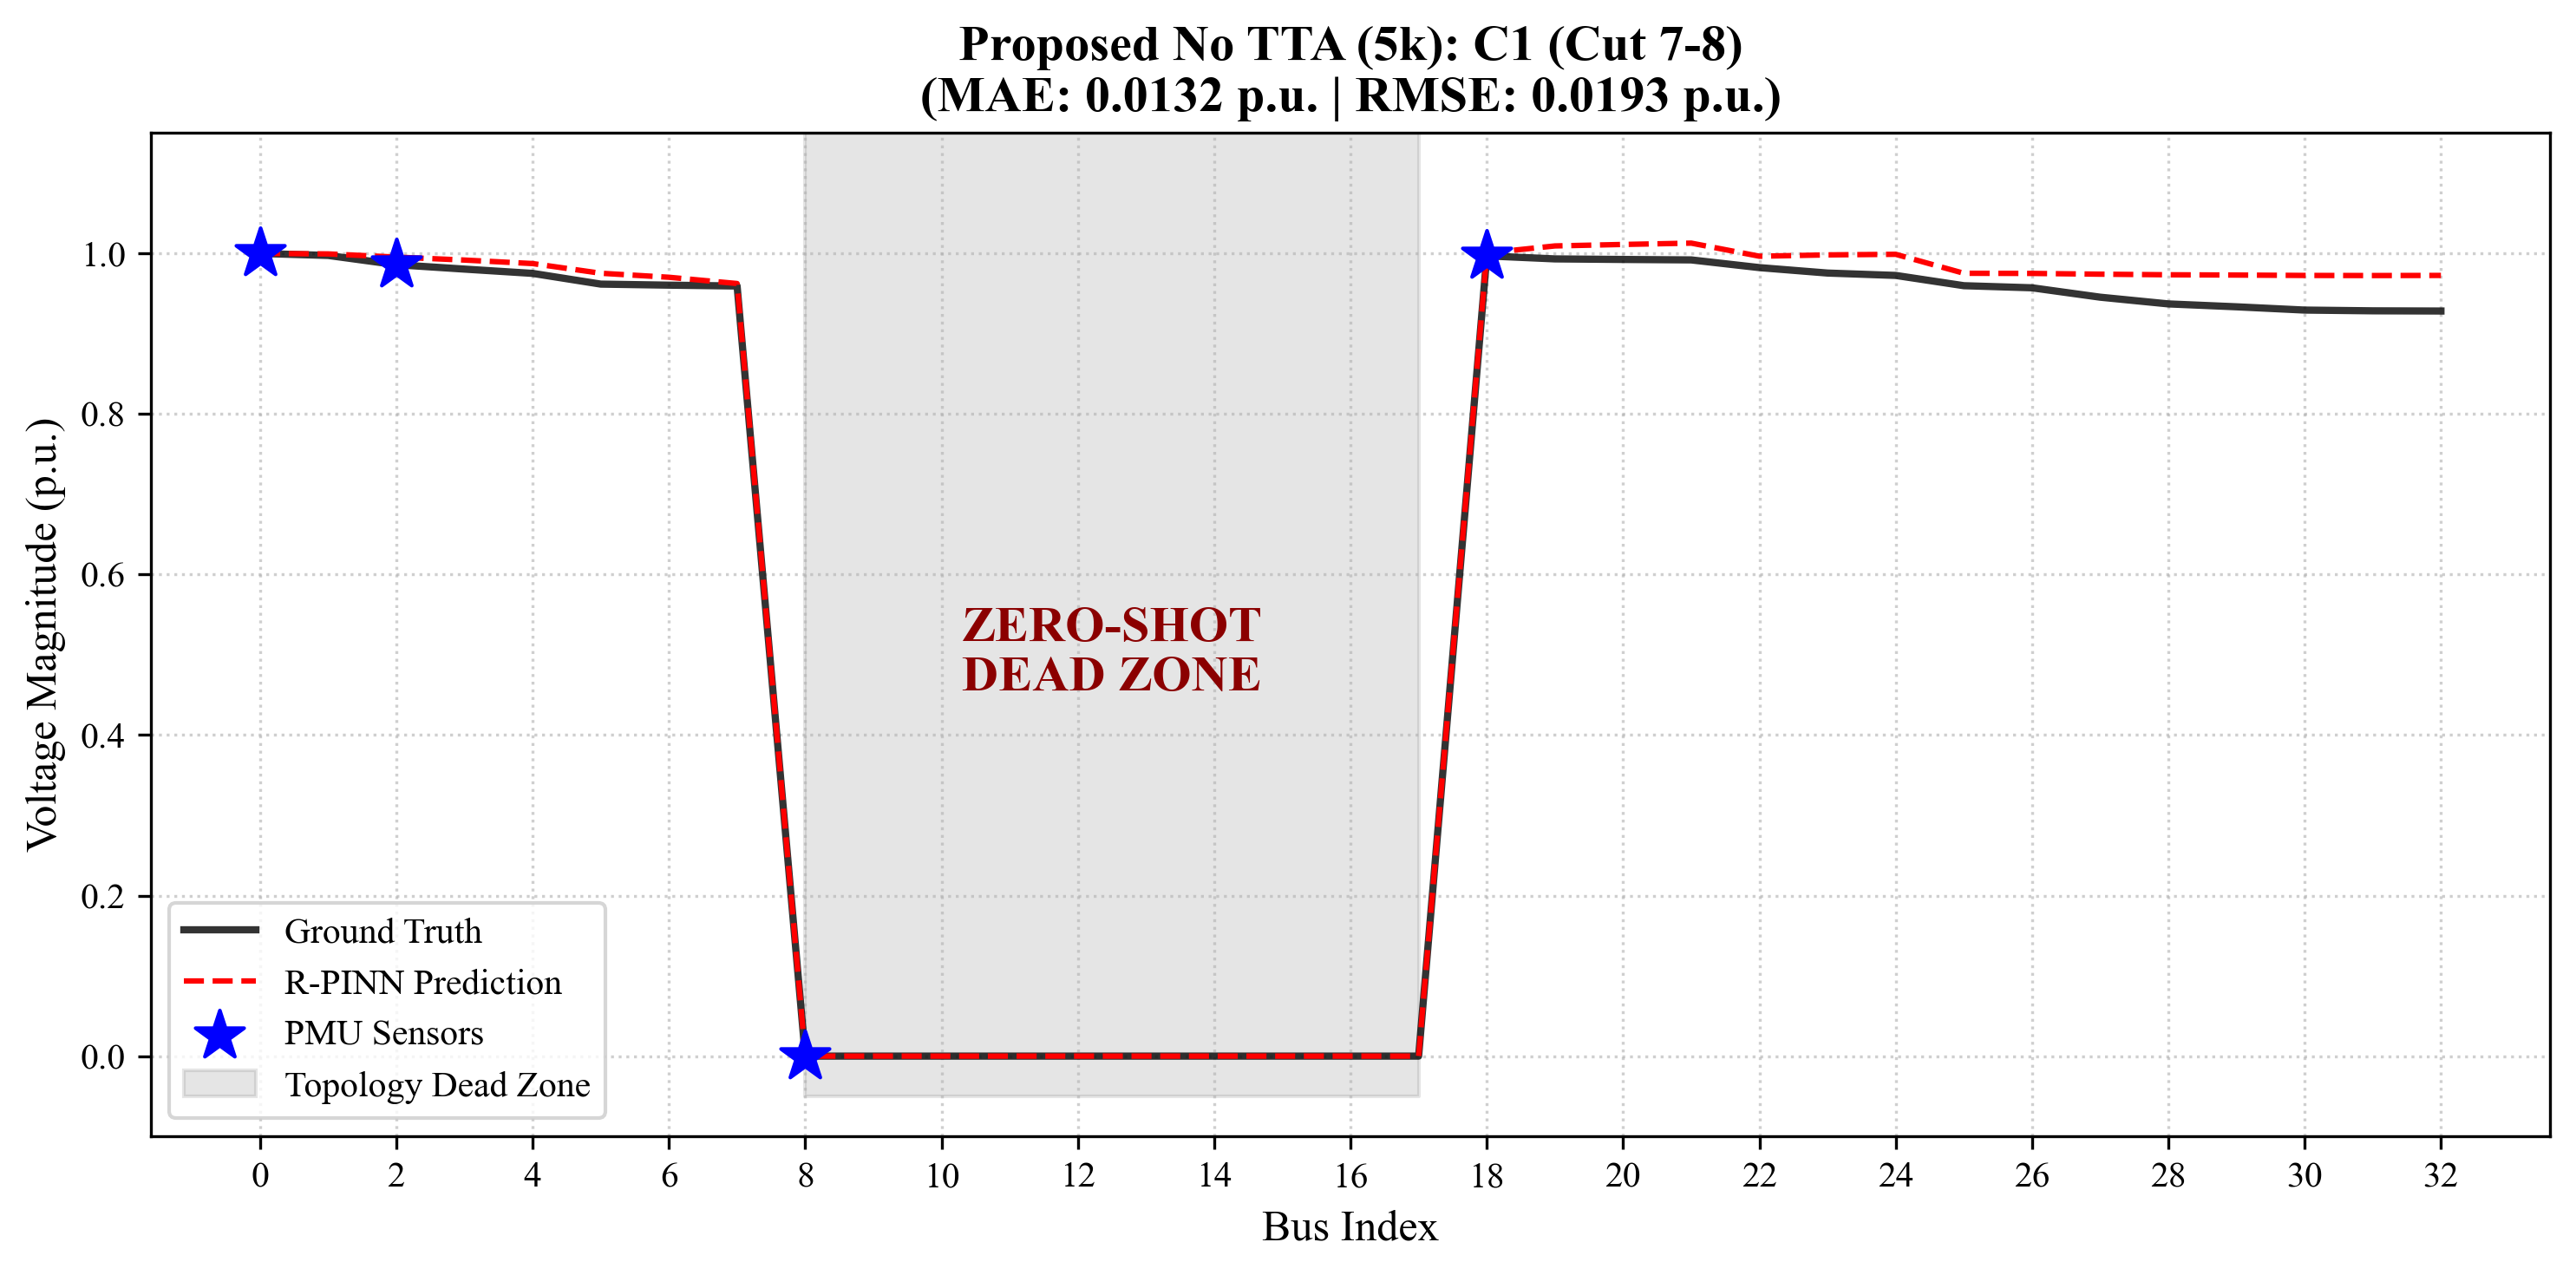


🔬 [NO TTA] 场景: C2 (Cut 13-14)
   • MAE:  1.816673e-02 p.u. | RMSE: 2.323241e-02 p.u. | RSE: 2.584818e-02
   🚫 物理死区识别: 节点 [14 15 16 17]


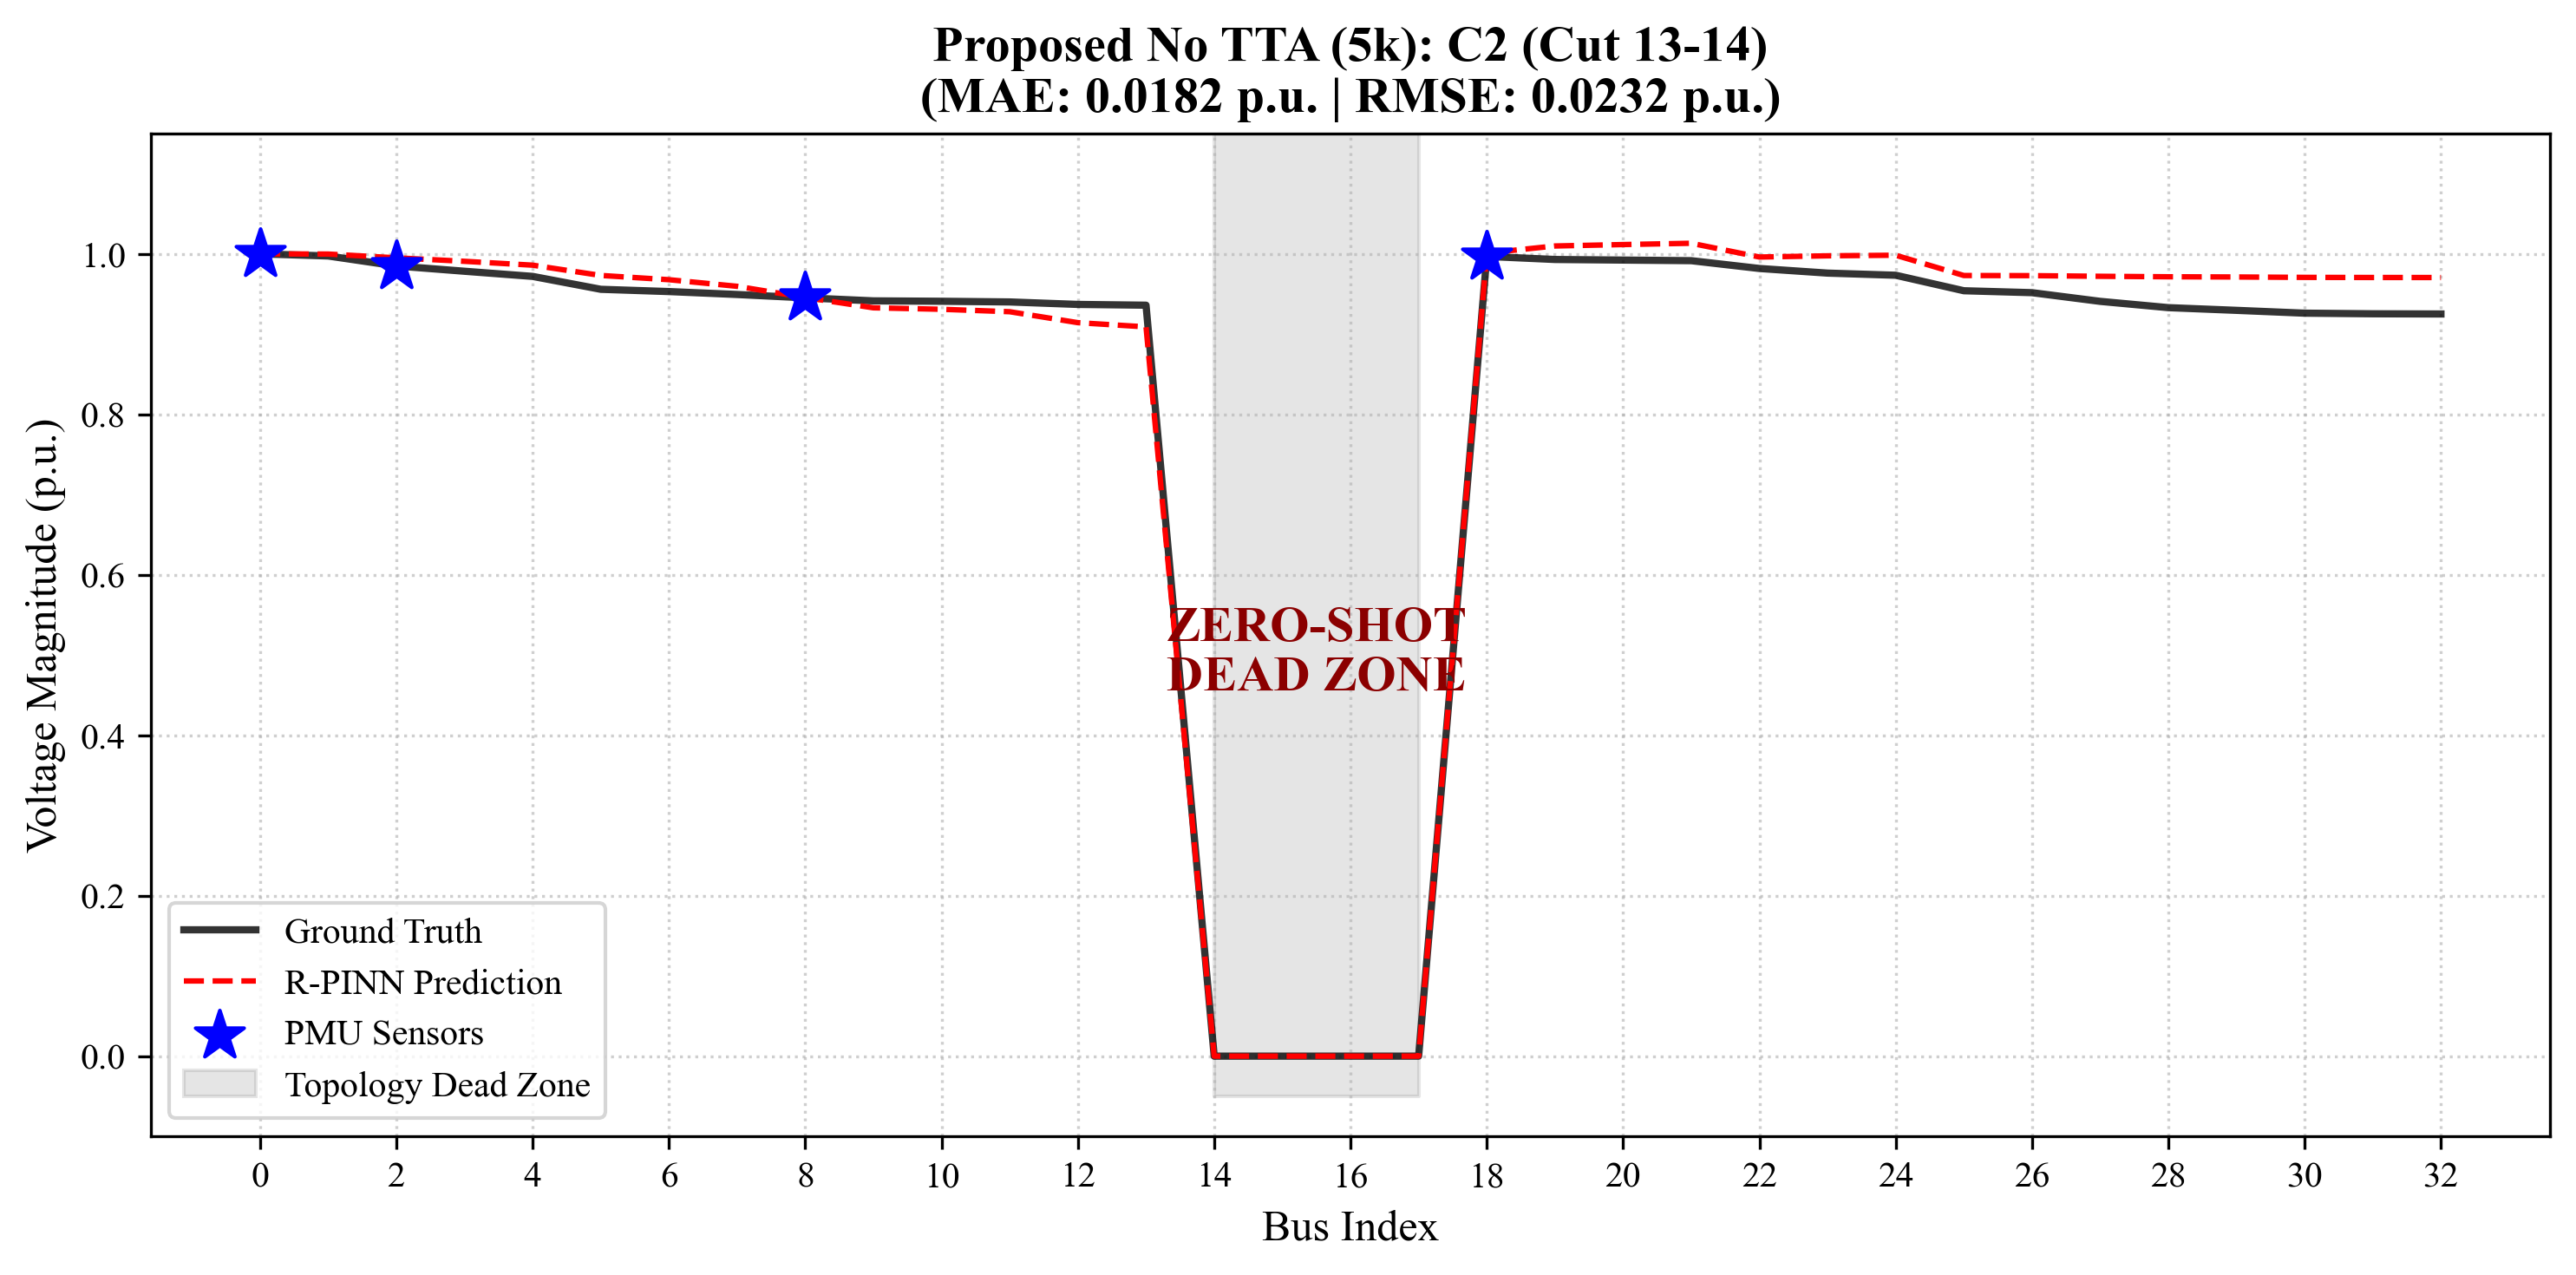


🔬 [NO TTA] 场景: C3 (Cut 6-26)
   • MAE:  1.197295e-02 p.u. | RMSE: 1.710091e-02 p.u. | RSE: 2.026791e-02
   🚫 物理死区识别: 节点 [25 26 27 28 29 30 31 32]


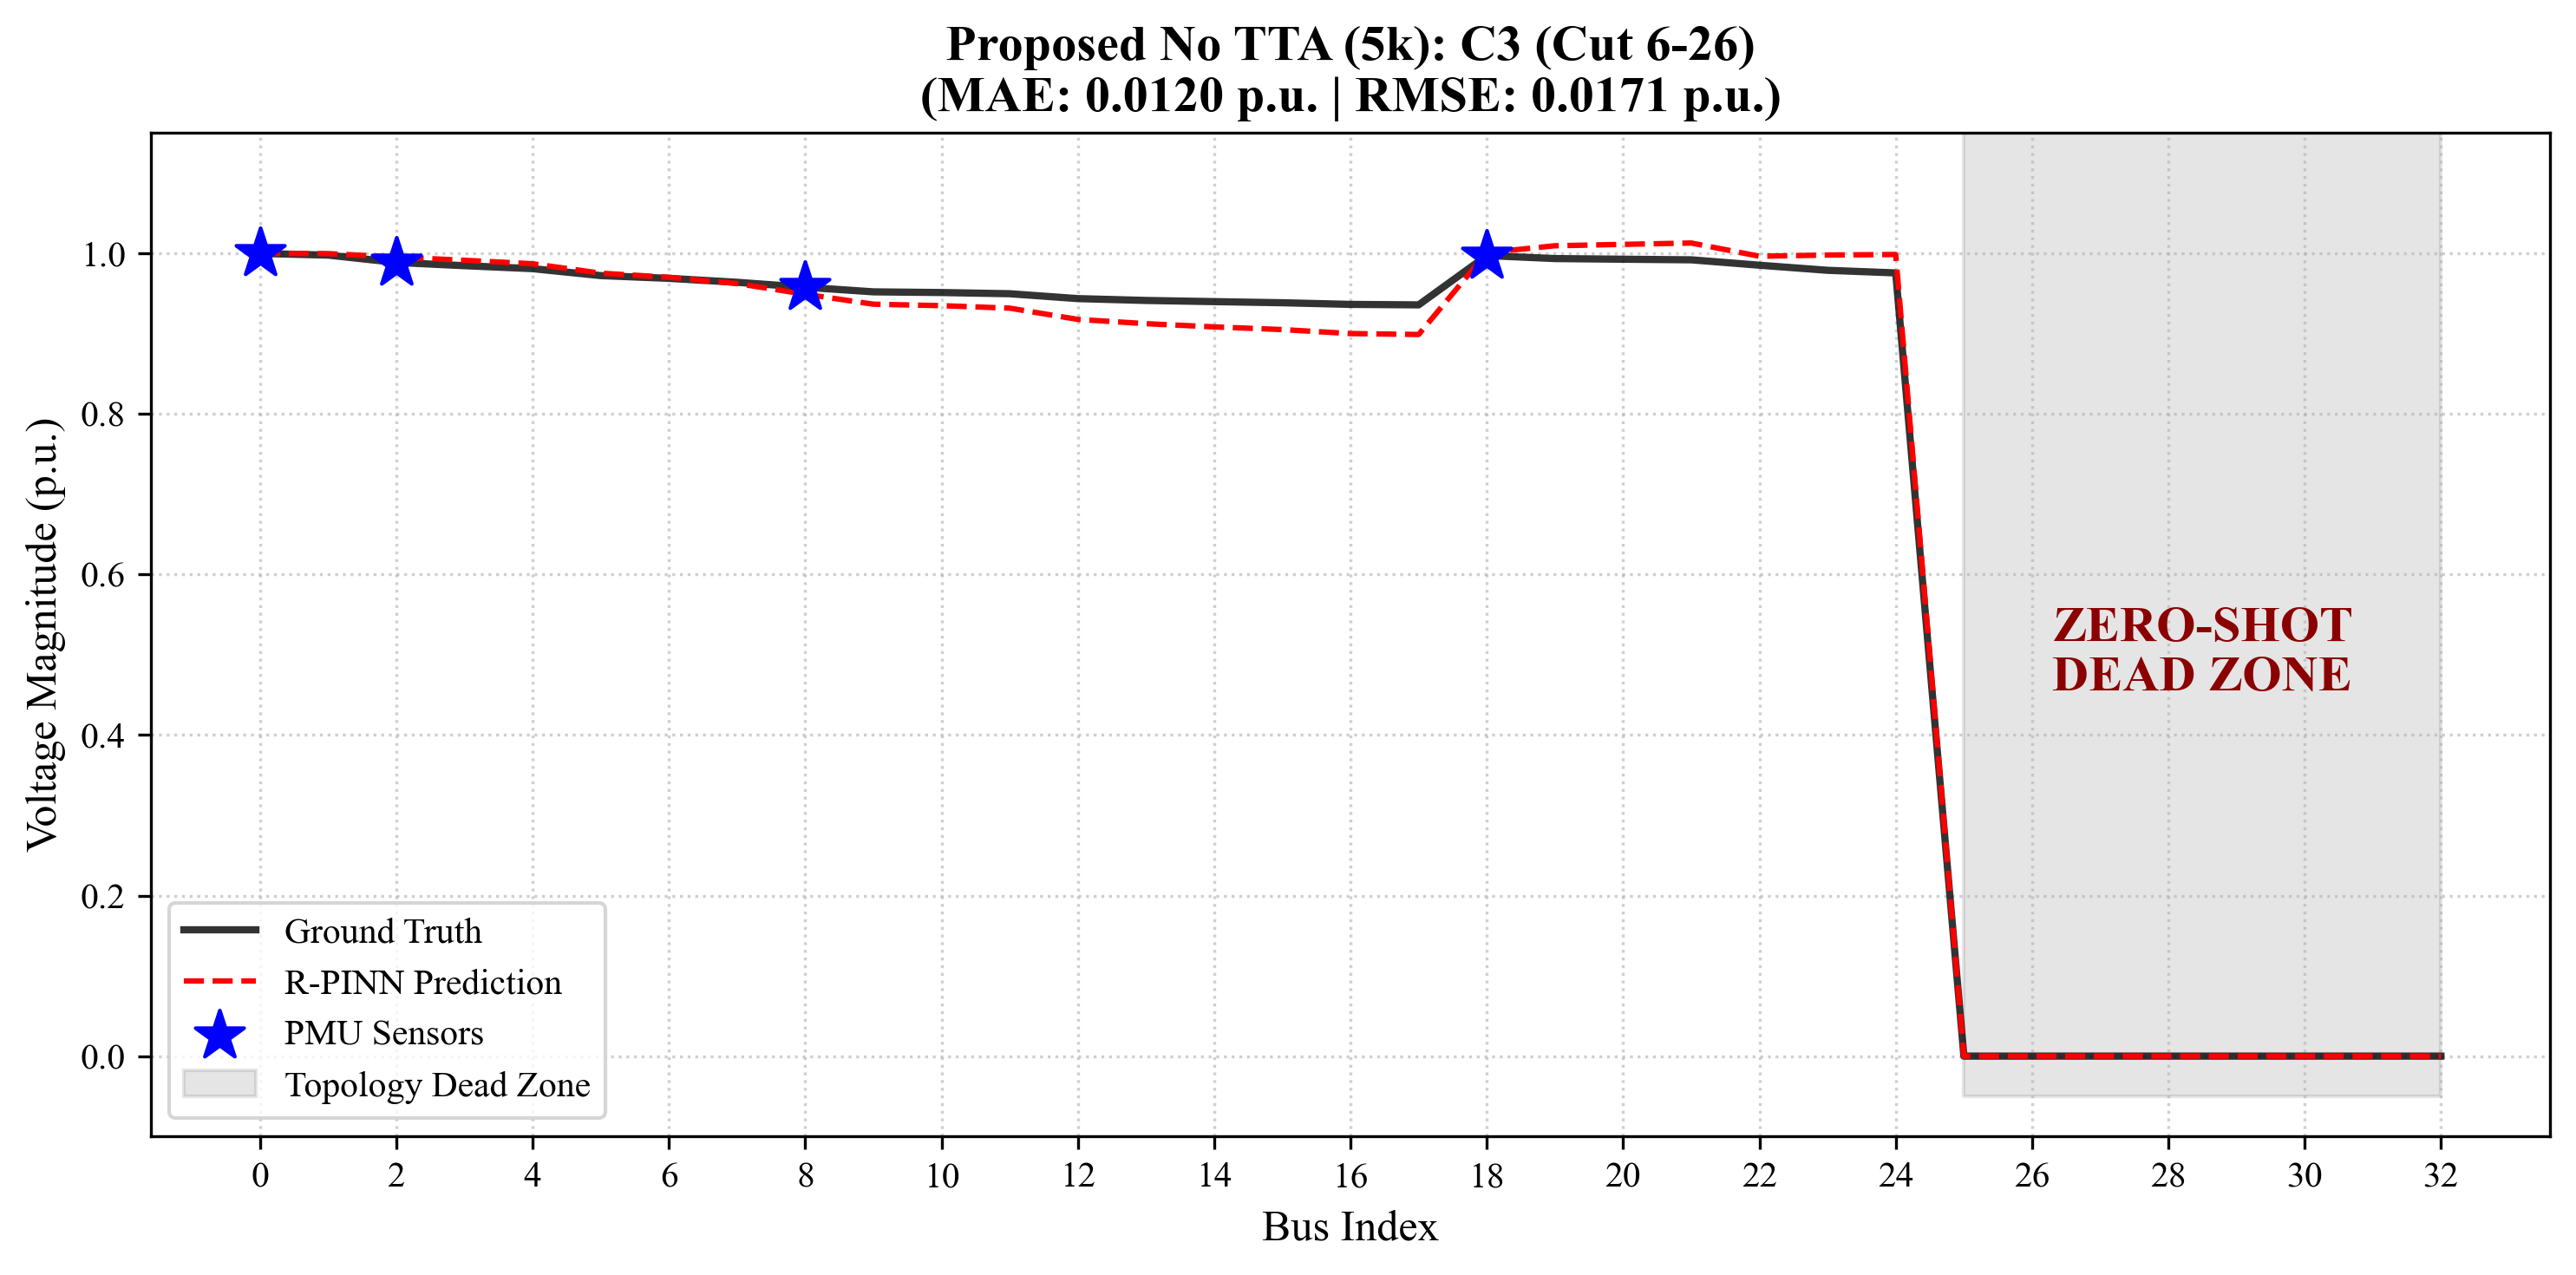


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
⚔️ Phase 2: 引入 Test-Time Adaptation (在线物理自适应)
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

⚡ 正在对 C1 (Cut 7-8) 进行在线物理重构 (20 轮 TTA)...
🔬 [TTA 增强] 场景: C1 (Cut 7-8)
   • MAE:  1.282948e-02 p.u. | RMSE: 1.859941e-02 p.u. | RSE: 2.300454e-02
   🚫 物理死区完美隔离: 节点 [ 8  9 10 11 12 13 14 15 16 17]


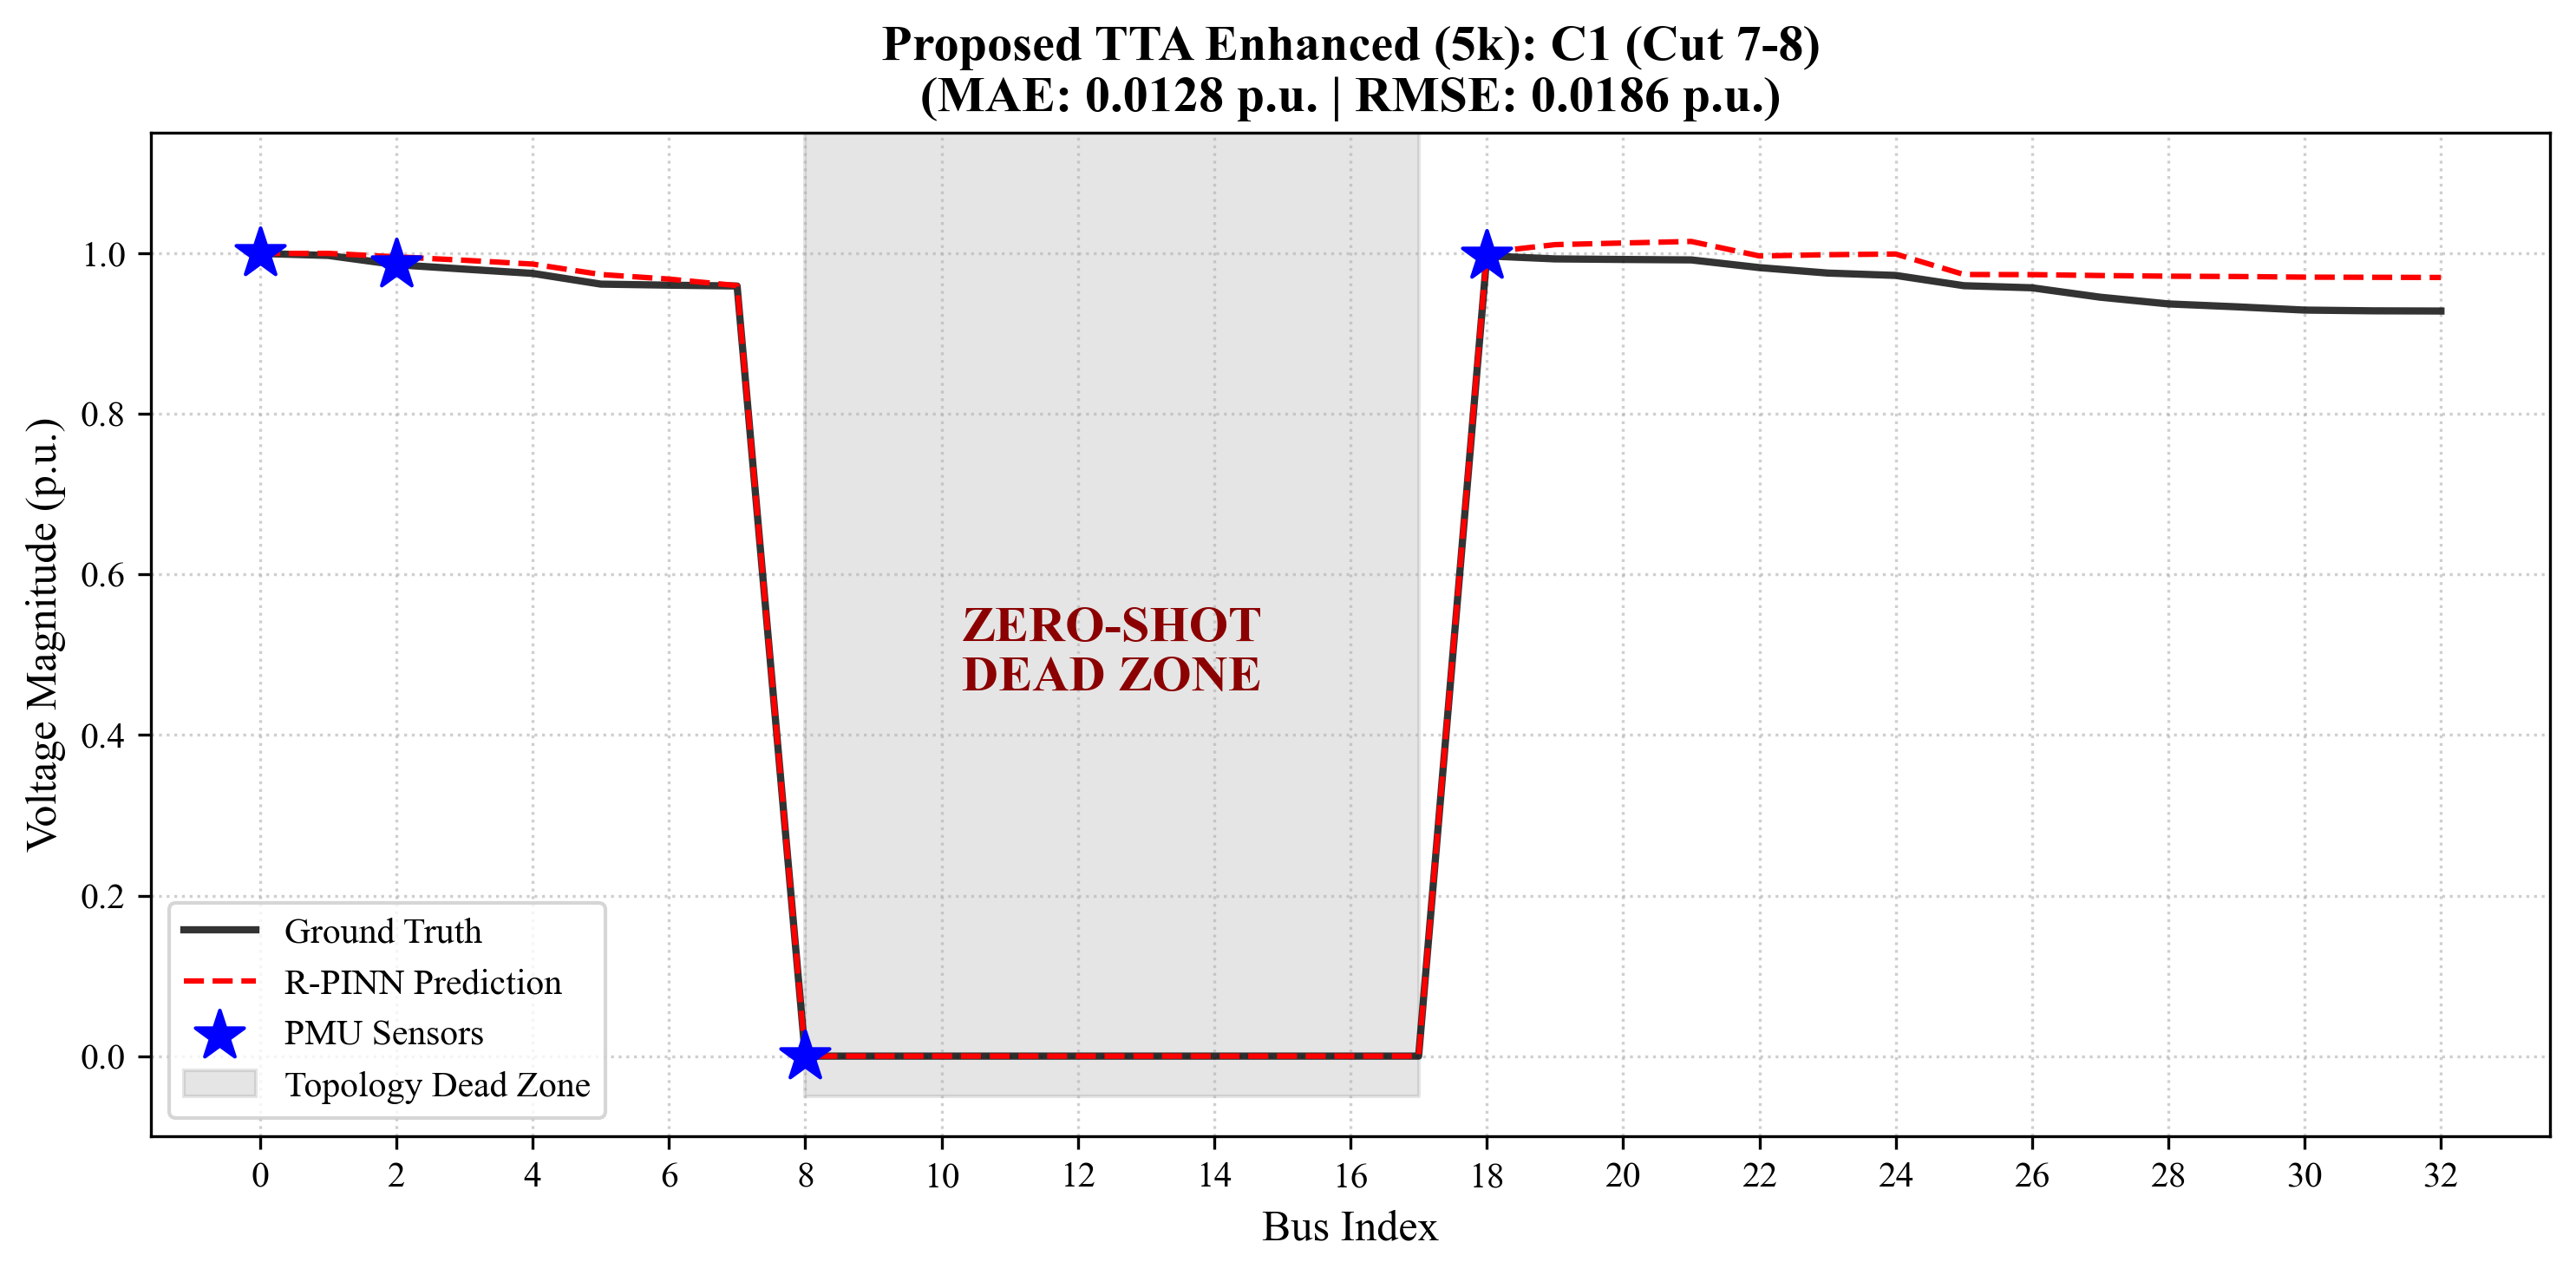


⚡ 正在对 C2 (Cut 13-14) 进行在线物理重构 (20 轮 TTA)...
🔬 [TTA 增强] 场景: C2 (Cut 13-14)
   • MAE:  1.730742e-02 p.u. | RMSE: 2.236253e-02 p.u. | RSE: 2.488036e-02
   🚫 物理死区完美隔离: 节点 [14 15 16 17]


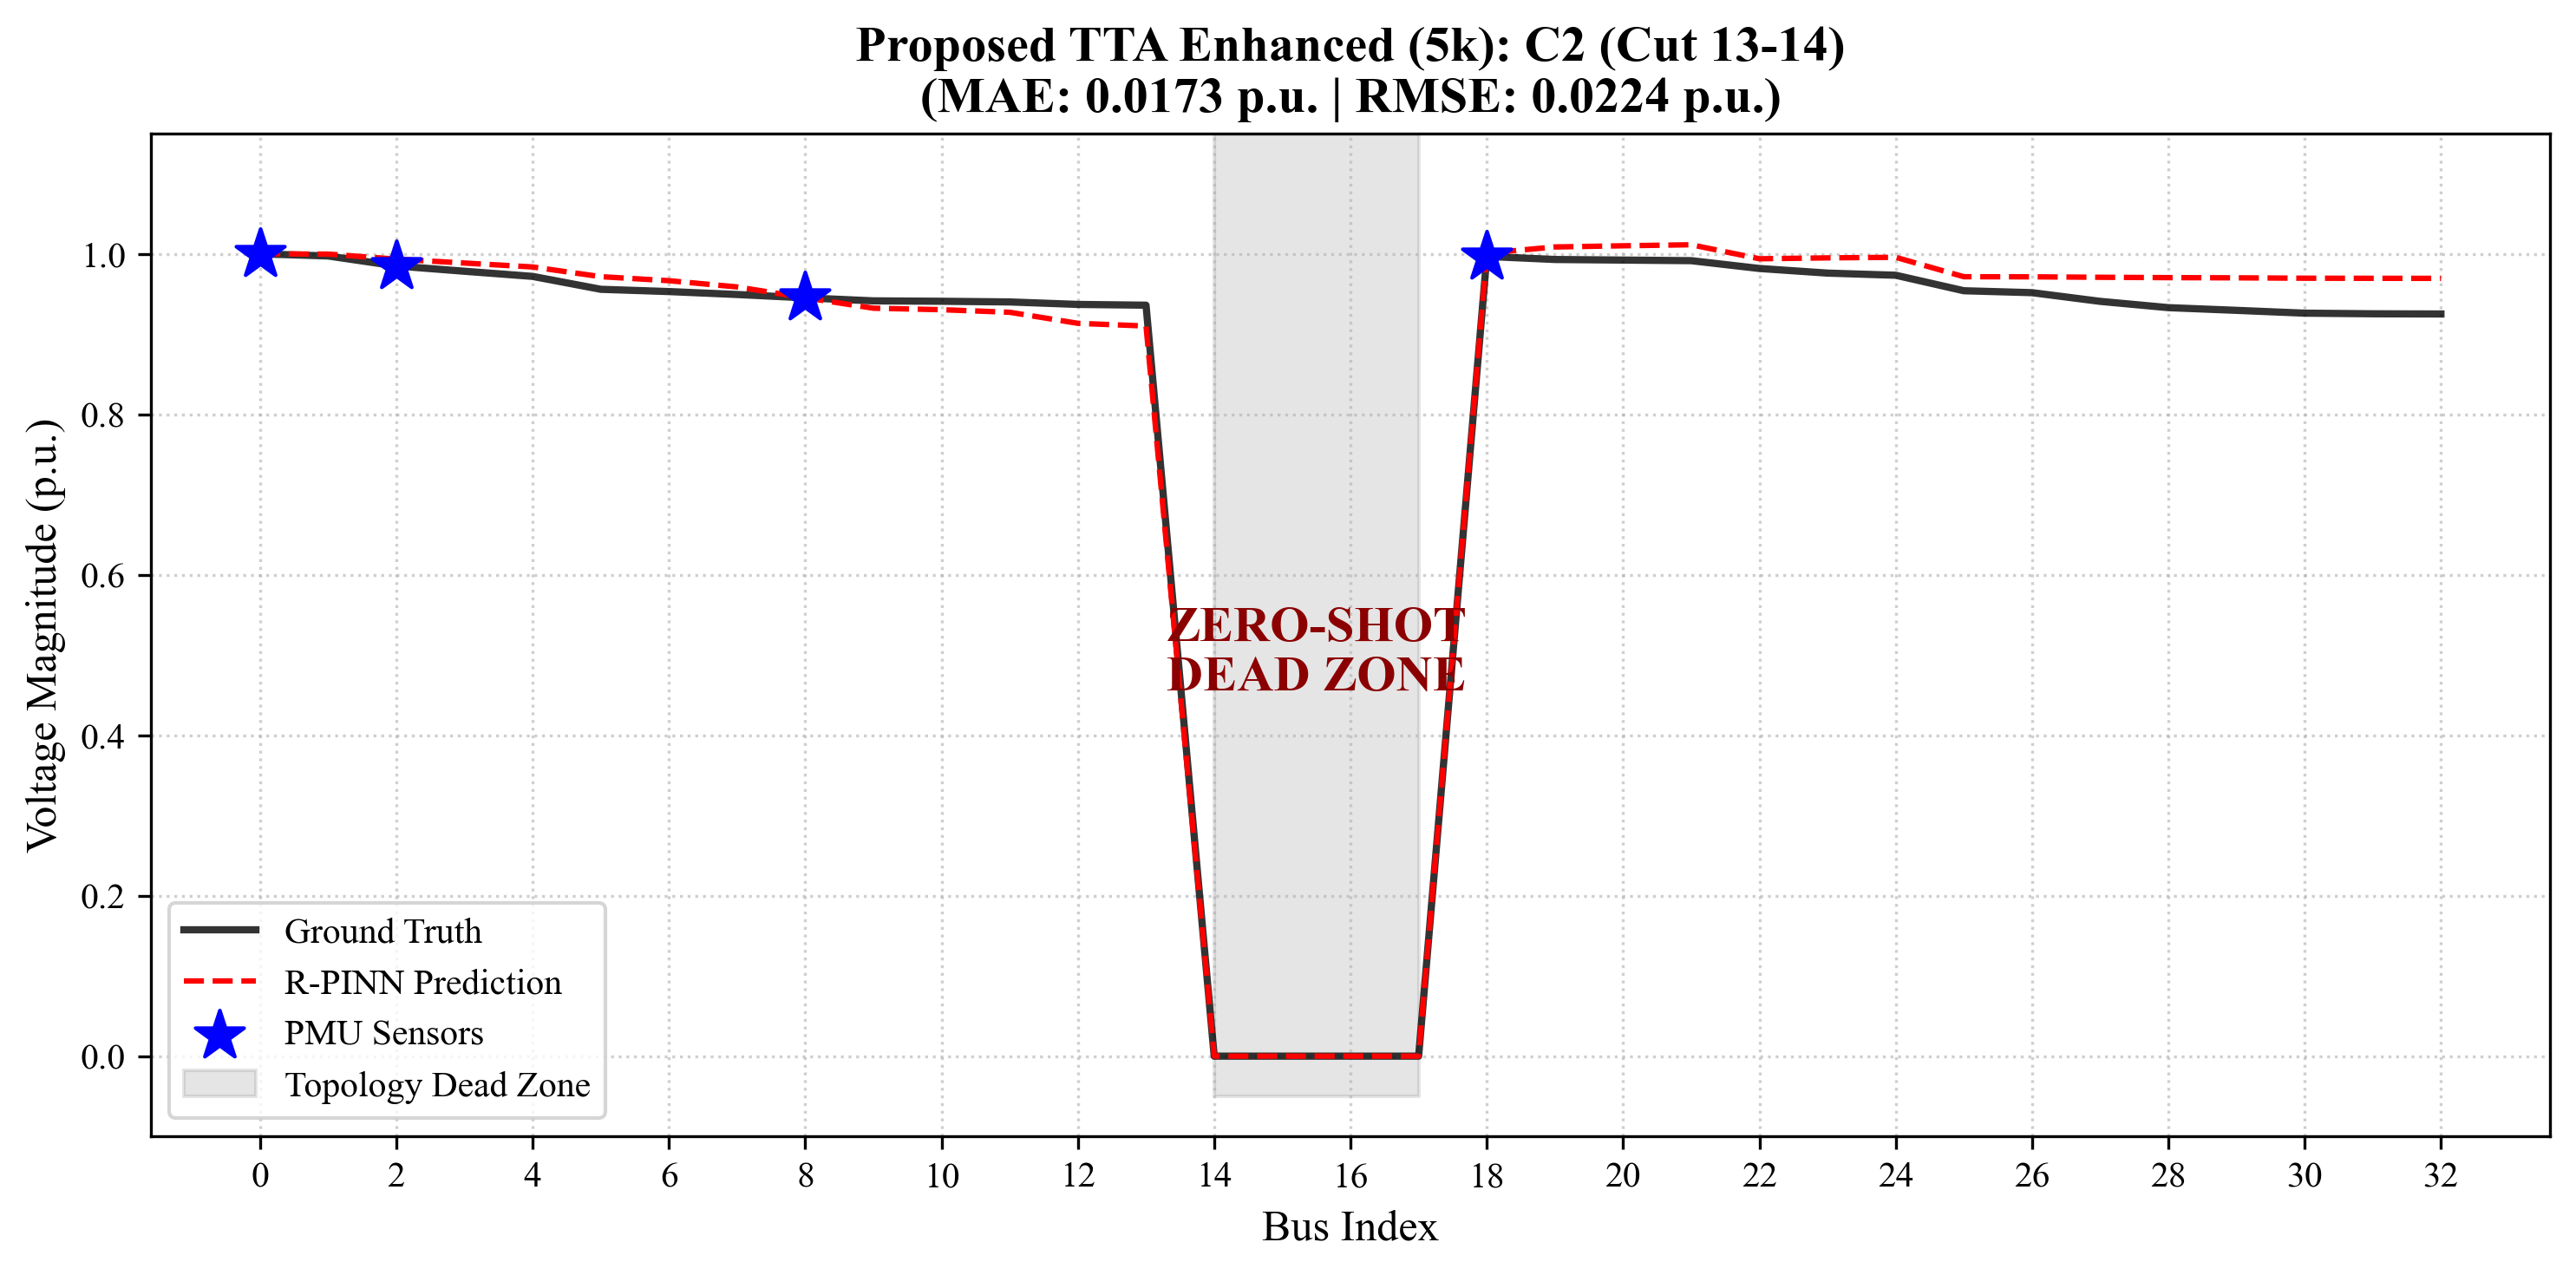


⚡ 正在对 C3 (Cut 6-26) 进行在线物理重构 (20 轮 TTA)...
🔬 [TTA 增强] 场景: C3 (Cut 6-26)
   • MAE:  1.056250e-02 p.u. | RMSE: 1.523369e-02 p.u. | RSE: 1.805488e-02
   🚫 物理死区完美隔离: 节点 [25 26 27 28 29 30 31 32]


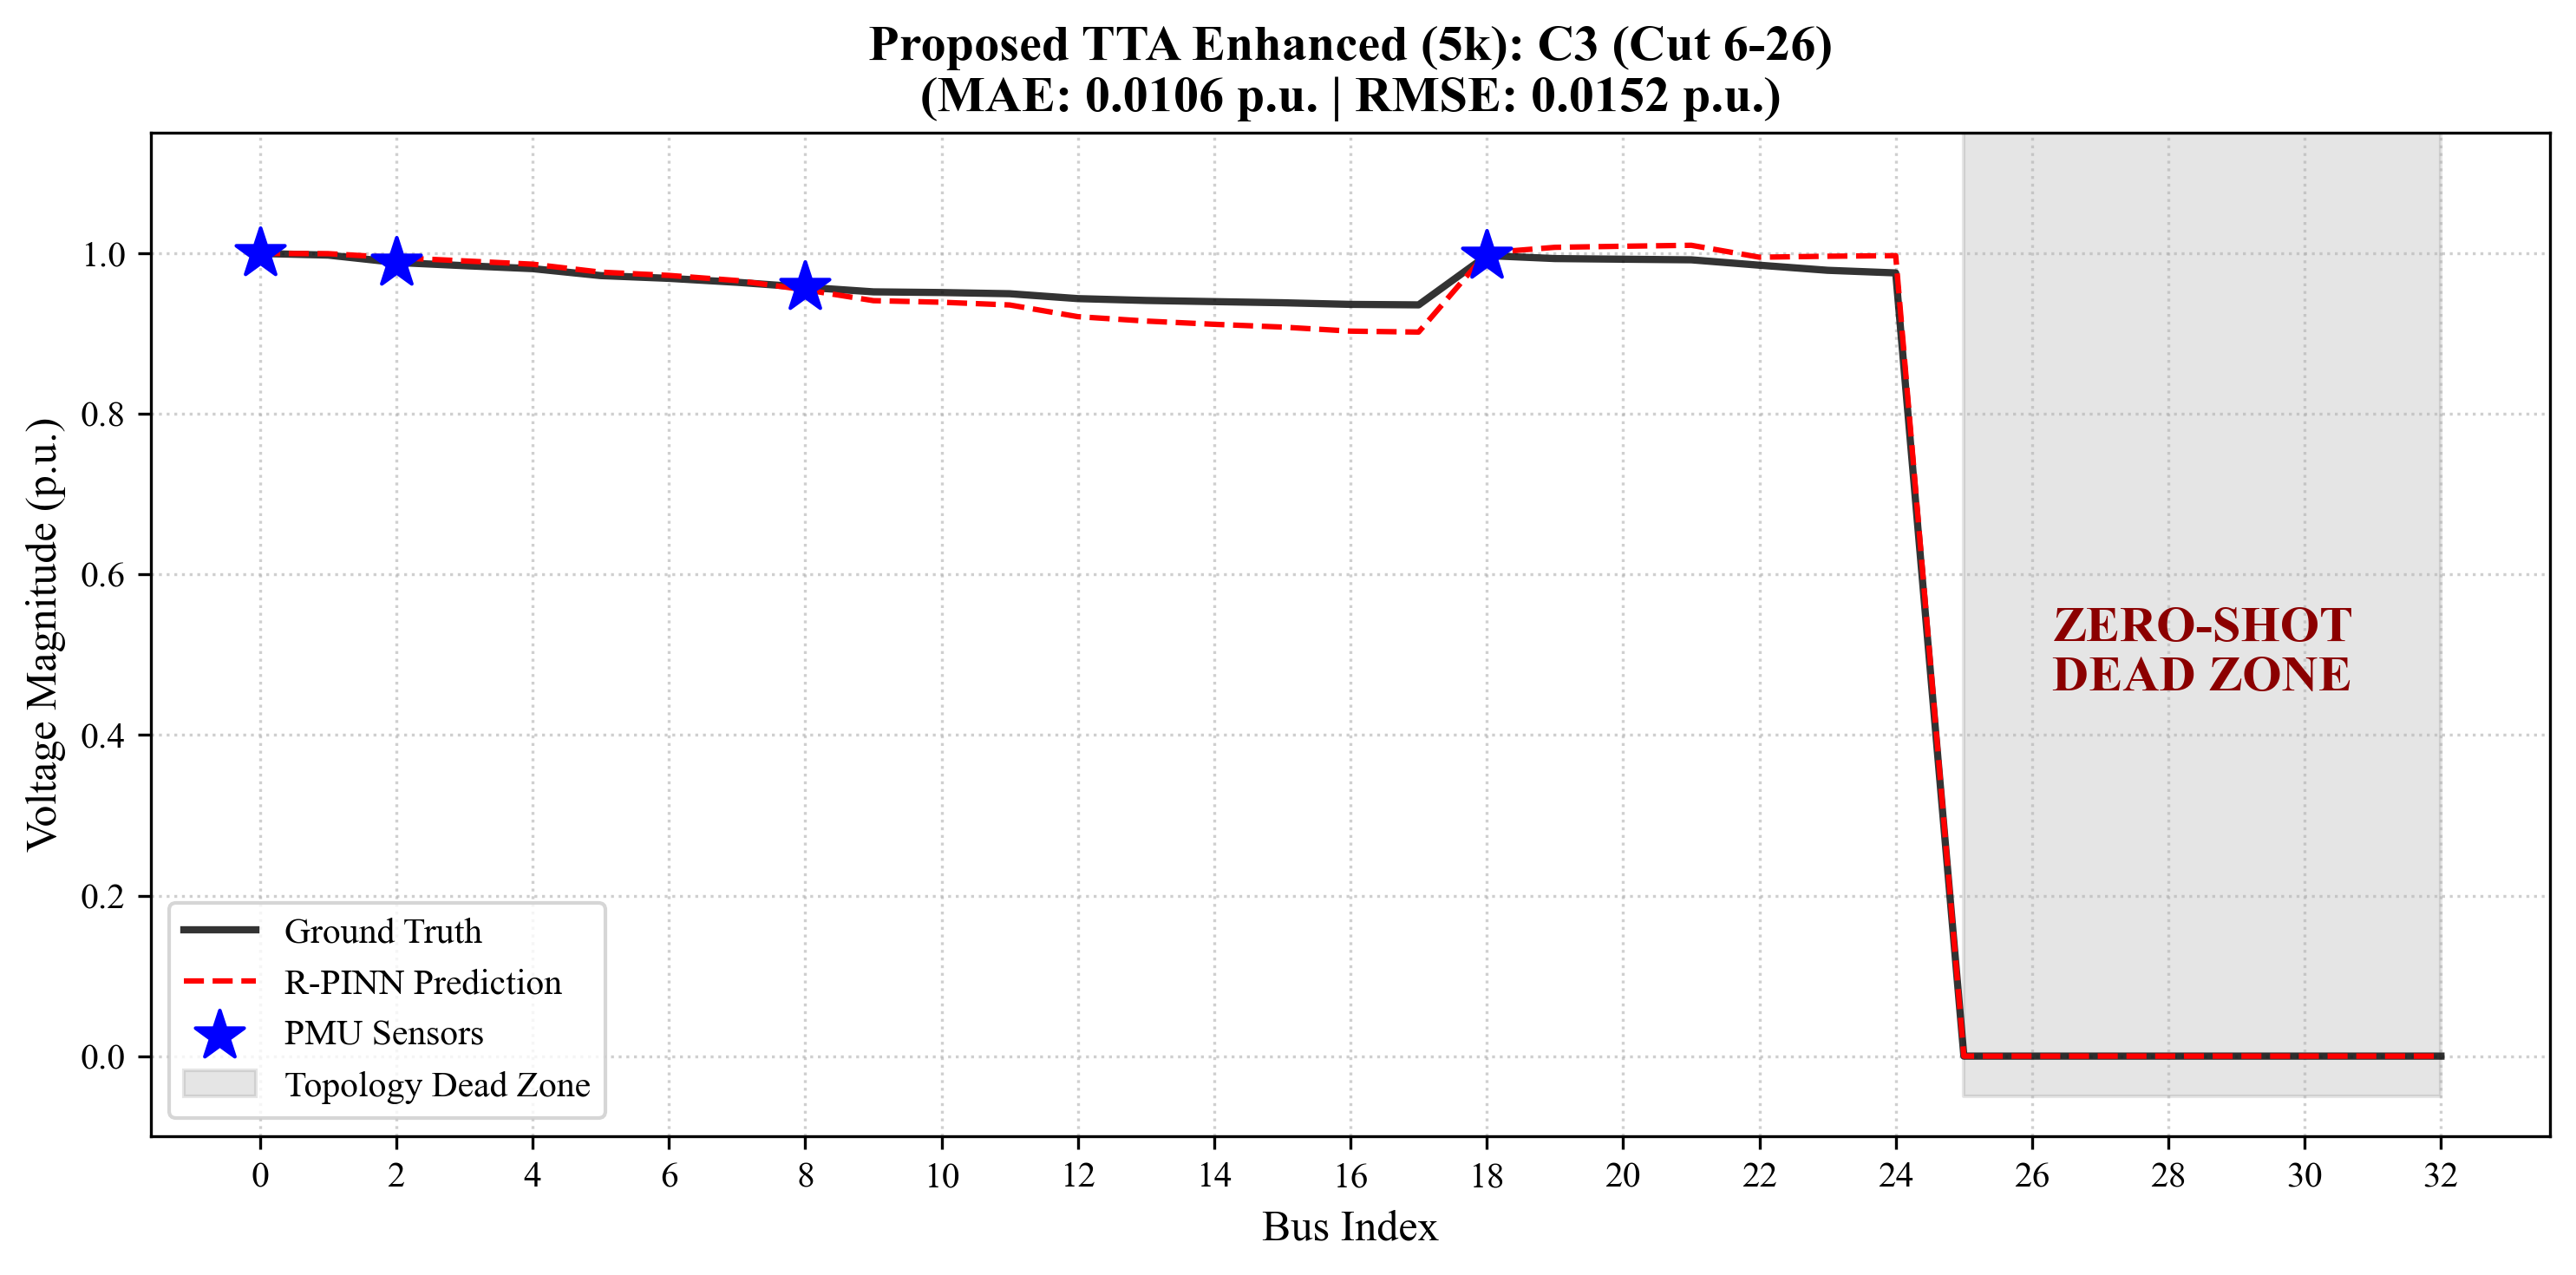

In [8]:
# ==============================================================================
# [IEEE Transactions 终极满血版] R-PINN 33节点：基态 -> Zero-shot -> TTA
# 核心杀器：ARS非对称残差缩放
# 全局同步：512 宽网络 + 独立 Mean-Loss 封装 + 降低惩罚权重 + TTA微操
# 实验条件：5000 条极少量样本 (Few-Shot)
# 严谨对账：已对齐 150轮 + StepLR 黄金配置！权重补偿彻底对齐 (obs_weight=2.5e6)
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
from collections import deque
import copy
import matplotlib.pyplot as plt

# --- 绘图风格设置 (学术顶刊质感) ---
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ------------------------------------------
# 🔒 1. 核心控制台：锁定随机性与配置
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_obs_indices(num_nodes=33, seed=42):
    random.seed(seed)
    num_obs = int(num_nodes * 0.15)  # 15% 极限盲区
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_obs_indices = get_obs_indices(33, 42)

print("=" * 65)
print(f"🚀 Proposed R-PINN 少样本战神舱 (5k) 就绪! 算力: {device}")
print(f"📡 锁定的 15% PMU 观测点: {global_obs_indices}")
print("=" * 65)

# ------------------------------------------
# ⚡ 2. 物理环境构建：提取 33 节点导纳矩阵
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

def build_ybus(cut_f_0idx=None, cut_t_0idx=None):
    y_bus = np.zeros((33, 33), dtype=complex)
    for i in range(len(branch_data)):
        f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
        if cut_f_0idx is not None and cut_t_0idx is not None:
            if (f == cut_f_0idx and t == cut_t_0idx) or (f == cut_t_0idx and t == cut_f_0idx):
                continue
        y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
        y_bus[f, f] += y_line
        y_bus[t, t] += y_line
        y_bus[f, t] = y_bus[t, f] = -y_line
    return torch.tensor(y_bus.real, dtype=torch.float32).to(device), torch.tensor(y_bus.imag, dtype=torch.float32).to(device)

G_tensor, B_tensor = build_ybus()

# ------------------------------------------
# 🧠 3. 核心引擎：512网络与独立 Mean Loss (有 ARS)
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]
        masked_x[:, idx + 33] = batch_x[:, idx + 33]
    return masked_x

def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    dT = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    p_term = G_t * torch.cos(dT) + B_t * torch.sin(dT)
    q_term = G_t * torch.sin(dT) - B_t * torch.cos(dT)
    return V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2), V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

def compute_loss_components(V_pred, theta_pred, P_real, Q_real, V_real, G, B, obs_idx):
    P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, G, B)

    P_loss = torch.mean((P_calc - P_real) ** 2)
    Q_loss = torch.mean((Q_calc - Q_real) ** 2)

    V_obs_pred, V_obs_real = V_pred[:, obs_idx], V_real[:, obs_idx]
    obs_loss = torch.mean((V_obs_pred - V_obs_real) ** 2)

    penalty_low = torch.nn.functional.relu(0.85 - V_pred)
    penalty_high = torch.nn.functional.relu(V_pred - 1.10)
    penalty_loss = torch.mean(penalty_low + penalty_high)

    return P_loss, Q_loss, obs_loss, penalty_loss

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU()
        )
        self.output_layers = nn.Linear(512, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)

        Vm_pred = 1.0 + 0.1 * output[:, :33]
        theta_pred = 0.0 + 0.1 * output[:, 33:]

        Vm_pred_clone = Vm_pred.clone(); theta_pred_clone = theta_pred.clone()
        Vm_pred_clone[:, 0] = 1.0; theta_pred_clone[:, 0] = 0.0
        return Vm_pred_clone, theta_pred_clone

class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx

    def forward(self, V_pred, theta_pred, P_real_target, Q_real_target, V_real, p_weight, obs_weight=2500000):
        P_loss, Q_loss, obs_loss, penalty_loss = compute_loss_components(
            V_pred, theta_pred, P_real_target, Q_real_target, V_real, self.G, self.B, self.obs_idx
        )
        return p_weight * (P_loss + Q_loss) + obs_weight * obs_loss + 100 * penalty_loss

class MyDataset(Dataset):
    def __init__(self, features, labels): self.features, self.labels = features, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

# ------------------------------------------
# 📥 4. 数据装载 (只取 5000 条！)
# ------------------------------------------
print("📥 正在读取 5,000 条 33 节点物理样本 (少样本实验)...")
df = pd.read_csv(r'IEEE33_50000_Safe_Final.csv').fillna(0.0)
raw_data = df.values.reshape(-1, 33, 4)

train_size = 5000
raw_data = raw_data[:train_size]

P_real_pu = raw_data[:, :, 0] / 100.0
Q_real_pu = raw_data[:, :, 1] / 100.0
V_real_pu = raw_data[:, :, 2]

ssl = StandardScaler()
X_norm = ssl.fit_transform(raw_data[:, :, 0:2].reshape(-1, 66))

mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
PQV_target_tensor = torch.tensor(np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1), dtype=torch.float32).to(device)
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(MyDataset(X_tensor, PQV_target_tensor), batch_size=128, shuffle=True, generator=g)

# ==============================================================================
# 🗡️ [战役一]：基态深度训练 (对齐黄金策略)
# ==============================================================================
model = PowerGridPINN(input_dim=66).to(device)

with torch.no_grad():
    model.output_layers.bias[:33].fill_(-0.5)

pinn_loss = PowerPINNLoss(G_tensor, B_tensor, global_obs_indices)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 🌟 黄金策略 1：StepLR
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

# 🌟 黄金策略 2：150 轮
max_epoch = 150
print("\n🔥 启动 R-PINN 基态深度训练 (带 ARS - 5000条数据 - 150轮黄金配置)...")

for epoch in range(max_epoch):
    # 🌟 黄金策略 3：物理权重提振时机对齐
    p_weight = 1000 if epoch < 50 else 5000
    model.train()
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer.zero_grad()
        real_p, real_q, real_v = batch_all_targets[:, :33], batch_all_targets[:, 33:66], batch_all_targets[:, 66:]
        mask_x = apply_blind_zone(batch_x, global_obs_indices, mean_tensor, scale_tensor)

        V_guess, theta_guess = model(mask_x)
        loss = pinn_loss(V_guess, theta_guess, real_p, real_q, real_v, p_weight, obs_weight=2500000)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    if epoch % 30 == 0 or epoch == max_epoch - 1:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss / len(train_loader):.4f} | LR: {optimizer.param_groups[0]['lr']:.6e}")

model.eval()
with torch.no_grad():
    pred_Vm_tensor, _ = model(apply_blind_zone(X_tensor[:1000], global_obs_indices, mean_tensor, scale_tensor))
    error = pred_Vm_tensor.cpu().numpy() - V_real_pu[:1000]
    mae_base = np.mean(np.abs(error))
    rmse_base = np.sqrt(np.mean(error ** 2))

print("\n" + "=" * 65)
print(f"🏆 [R-PINN 对账单] 基态性能 (有 ARS - 5000条数据 - 黄金策略)")
print(f"🌍 Overall MAE: {mae_base:.6e} p.u. | RMSE: {rmse_base:.6e} p.u.")
print("=" * 65)

# ------------------------------------------
# 🔧 辅助工具箱：拓扑识别、指标计算、出图
# ------------------------------------------
def get_topology_mask(G_np, B_np, num_nodes=33, root=0):
    mask = np.zeros(num_nodes, dtype=np.float32)
    adj = (np.abs(G_np) > 1e-6) | (np.abs(B_np) > 1e-6)
    q = deque([root]);
    mask[root] = 1.0
    while q:
        u = q.popleft()
        for v in np.where(adj[u])[0]:
            if mask[v] == 0: mask[v] = 1.0; q.append(v)
    return torch.tensor(mask, dtype=torch.float32).to(device)

def calculate_safe_metrics(v_pred, v_true):
    eps = 1e-12
    err = v_pred - v_true
    mae = torch.mean(torch.abs(err)).item()
    rmse = torch.sqrt(torch.mean(err ** 2)).item()
    rmae = (torch.sum(torch.abs(err)) / (torch.sum(torch.abs(v_true)) + eps)).item()
    rse = (torch.sqrt(torch.sum(err ** 2)) / (torch.sqrt(torch.sum(v_true ** 2)) + eps)).item()
    return mae, rmse, rmae, rse

def plot_academic_case(nodes, v_true, v_pred, pmu_idx, mask, title, mae_val, rmse_val):
    plt.figure(figsize=(10, 5))
    plt.plot(nodes, v_true, 'k-', label='Ground Truth', linewidth=2, alpha=0.8)
    plt.plot(nodes, v_pred, 'r--', label='R-PINN Prediction', linewidth=1.5)
    plt.scatter(pmu_idx, v_true[pmu_idx], color='blue', marker='*', s=200, label='PMU Sensors', zorder=5)

    dead_nodes = np.where(mask == 0)[0]
    if len(dead_nodes) > 0:
        plt.fill_between(dead_nodes, -0.05, 1.15, color='gray', alpha=0.2, label='Topology Dead Zone')
        plt.text(np.mean(dead_nodes), 0.5, 'ZERO-SHOT\nDEAD ZONE', color='darkred',
                 fontsize=14, fontweight='bold', ha='center', va='center')

    plt.title(f"{title}\n(MAE: {mae_val:.4f} p.u. | RMSE: {rmse_val:.4f} p.u.)", fontsize=14, fontweight='bold')
    plt.xlabel('Bus Index', fontsize=12)
    plt.ylabel('Voltage Magnitude (p.u.)', fontsize=12)
    plt.ylim(-0.1, 1.15)
    plt.xticks(nodes[::2])
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left', fontsize=10)
    plt.tight_layout()
    plt.show()

test_cases = [
    {"n": "C1 (Cut 7-8)", "csv": "data_33_C1.csv", "cut": (7, 8)},
    {"n": "C2 (Cut 13-14)", "csv": "data_33_C2.csv", "cut": (13, 14)},
    {"n": "C3 (Cut 6-26)", "csv": "data_33_C3.csv", "cut": (5, 25)}
]
nodes = np.arange(33)

# ==============================================================================
# 🛡️ [战役二]：Zero-shot 零样本直突 
# ==============================================================================
print("\n" + "🔥" * 25)
print("🛡️ Phase 1: Zero-shot 零样本断线对账 (无 TTA)")
print("🔥" * 25)

with torch.no_grad():
    for case in test_cases:
        try:
            df_c = pd.read_csv(case["csv"]).fillna(0.0)
            raw_c = df_c.values.reshape(-1, 33, 4)
            X_c = torch.tensor(ssl.transform(raw_c[:, :, 0:2].reshape(-1, 66)), dtype=torch.float32).to(device)
            V_t = torch.tensor(raw_c[:, :, 2], dtype=torch.float32).to(device)

            G_f, B_f = build_ybus(case["cut"][0], case["cut"][1])
            mask_t = get_topology_mask(G_f.cpu().numpy(), B_f.cpu().numpy())

            V_raw, _ = model(apply_blind_zone(X_c, global_obs_indices, mean_tensor, scale_tensor))
            V_final = V_raw * mask_t

            mae, rmse, rmae, rse = calculate_safe_metrics(V_final, V_t * mask_t)
            print(f"\n🔬 [NO TTA] 场景: {case['n']}")
            print(f"   • MAE:  {mae:.6e} p.u. | RMSE: {rmse:.6e} p.u. | RSE: {rse:.6e}")
            print(f"   🚫 物理死区识别: 节点 {torch.where(mask_t == 0)[0].cpu().numpy()}")

            plot_academic_case(nodes, (V_t[0] * mask_t).cpu().numpy(), V_final[0].cpu().numpy(),
                               global_obs_indices, mask_t.cpu().numpy(), f"Proposed No TTA (5k): {case['n']}", mae, rmse)
        except Exception as e:
            print(f"❌ 运行故障 ({case['n']}): {e}")

# ==============================================================================
# ⚔️ [战役三]：在线物理自适应 TTA 
# ==============================================================================
print("\n" + "🔥" * 25)
print("⚔️ Phase 2: 引入 Test-Time Adaptation (在线物理自适应)")
print("🔥" * 25)

for case in test_cases:
    try:
        df_c = pd.read_csv(case["csv"]).fillna(0.0)
        raw_c = df_c.values.reshape(-1, 33, 4)
        X_c = torch.tensor(ssl.transform(raw_c[:, :, 0:2].reshape(-1, 66)), dtype=torch.float32).to(device)
        V_t = torch.tensor(raw_c[:, :, 2], dtype=torch.float32).to(device)

        G_f, B_f = build_ybus(case["cut"][0], case["cut"][1])
        mask_t = get_topology_mask(G_f.cpu().numpy(), B_f.cpu().numpy())

        model_tta = copy.deepcopy(model)
        model_tta.train()
        pinn_loss_tta = PowerPINNLoss(G_f, B_f, global_obs_indices)

        optimizer_tta = torch.optim.Adam(model_tta.parameters(), lr=1e-5)

        print(f"\n⚡ 正在对 {case['n']} 进行在线物理重构 (20 轮 TTA)...")
        masked_x_tta = apply_blind_zone(X_c[0:1], global_obs_indices, mean_tensor, scale_tensor)

        for tta_epoch in range(20):
            optimizer_tta.zero_grad()
            V_guess, theta_guess = model_tta(masked_x_tta)

            P_zero = torch.zeros_like(V_guess).to(device)
            Q_zero = torch.zeros_like(V_guess).to(device)

            loss = pinn_loss_tta(V_guess, theta_guess, P_zero, Q_zero, V_t[0:1], p_weight=5000, obs_weight=10000000)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tta.parameters(), max_norm=1.0)
            optimizer_tta.step()

        model_tta.eval()
        with torch.no_grad():
            V_raw, _ = model_tta(apply_blind_zone(X_c, global_obs_indices, mean_tensor, scale_tensor))
            V_final = V_raw * mask_t

            mae, rmse, rmae, rse = calculate_safe_metrics(V_final, V_t * mask_t)

            print(f"🔬 [TTA 增强] 场景: {case['n']}")
            print(f"   • MAE:  {mae:.6e} p.u. | RMSE: {rmse:.6e} p.u. | RSE: {rse:.6e}")
            print(f"   🚫 物理死区完美隔离: 节点 {torch.where(mask_t == 0)[0].cpu().numpy()}")

            plot_academic_case(nodes, (V_t[0] * mask_t).cpu().numpy(), V_final[0].cpu().numpy(),
                               global_obs_indices, mask_t.cpu().numpy(), f"Proposed TTA Enhanced (5k): {case['n']}", mae,
                               rmse)

    except Exception as e:
        print(f"❌ TTA 运行故障 ({case['n']}): {e}")

✅ 第一张神图 (三方会战) 生成完毕！
✅ 第二张神图 (数据效能打击) 生成完毕！


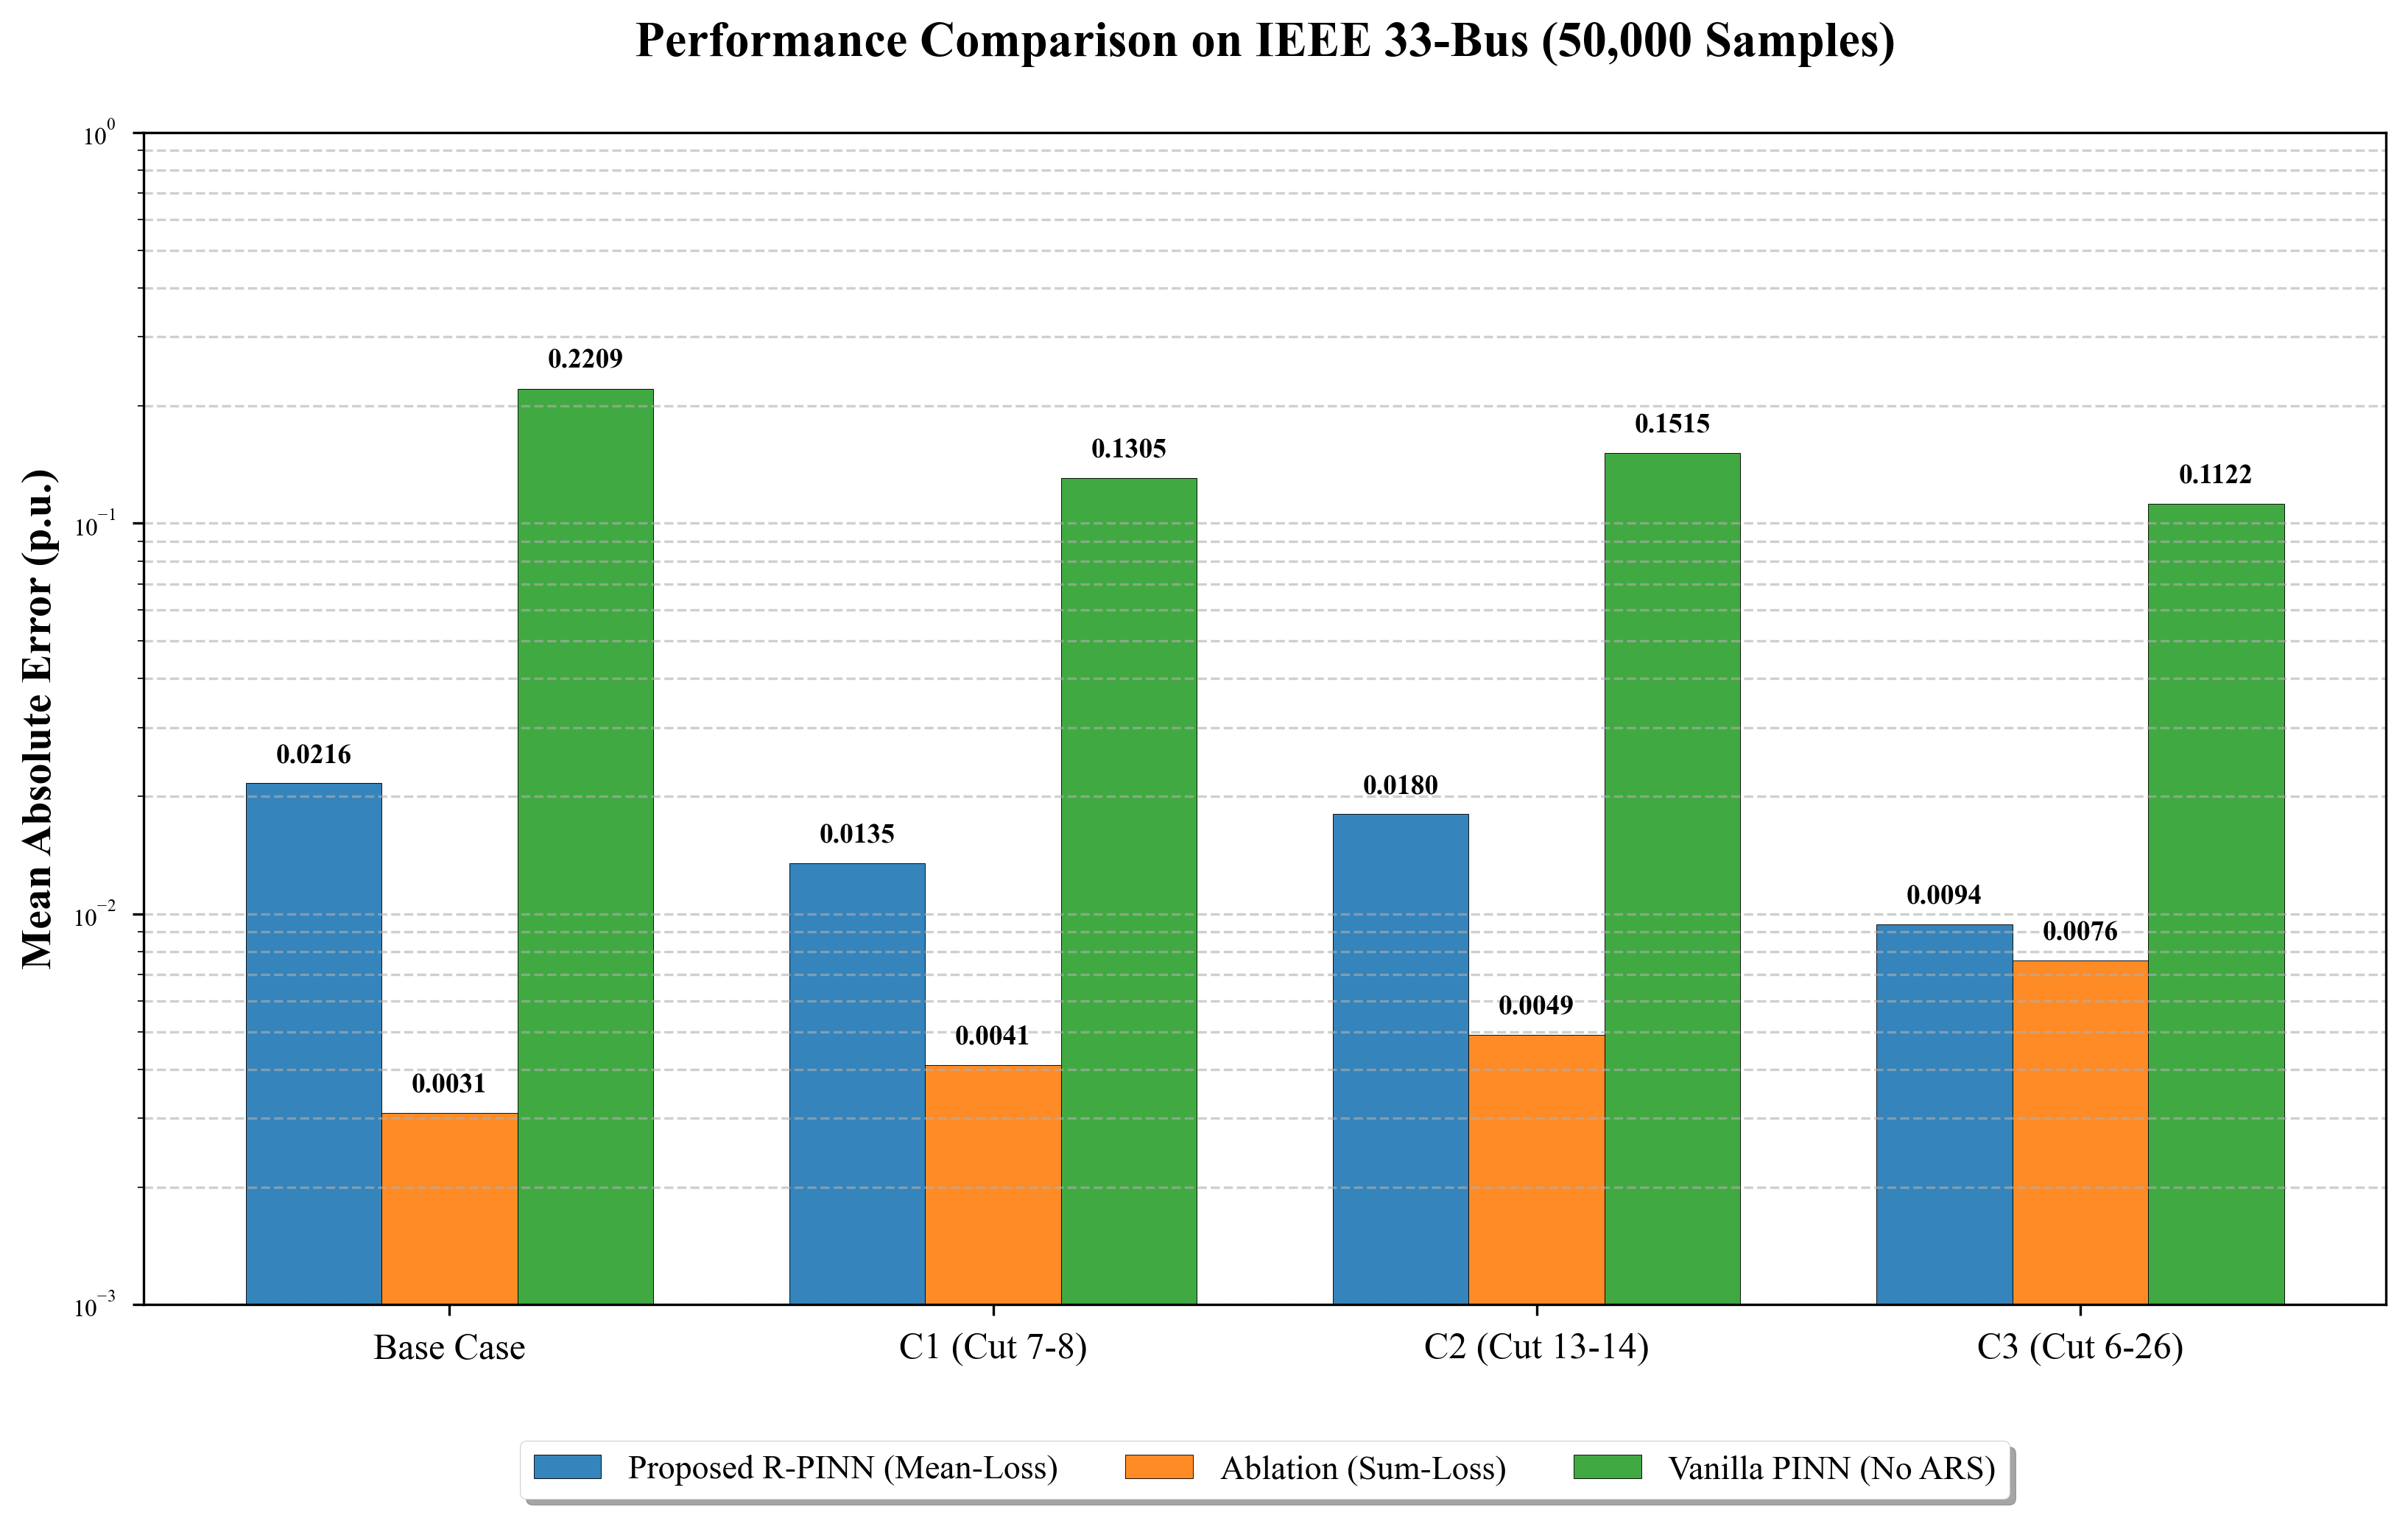

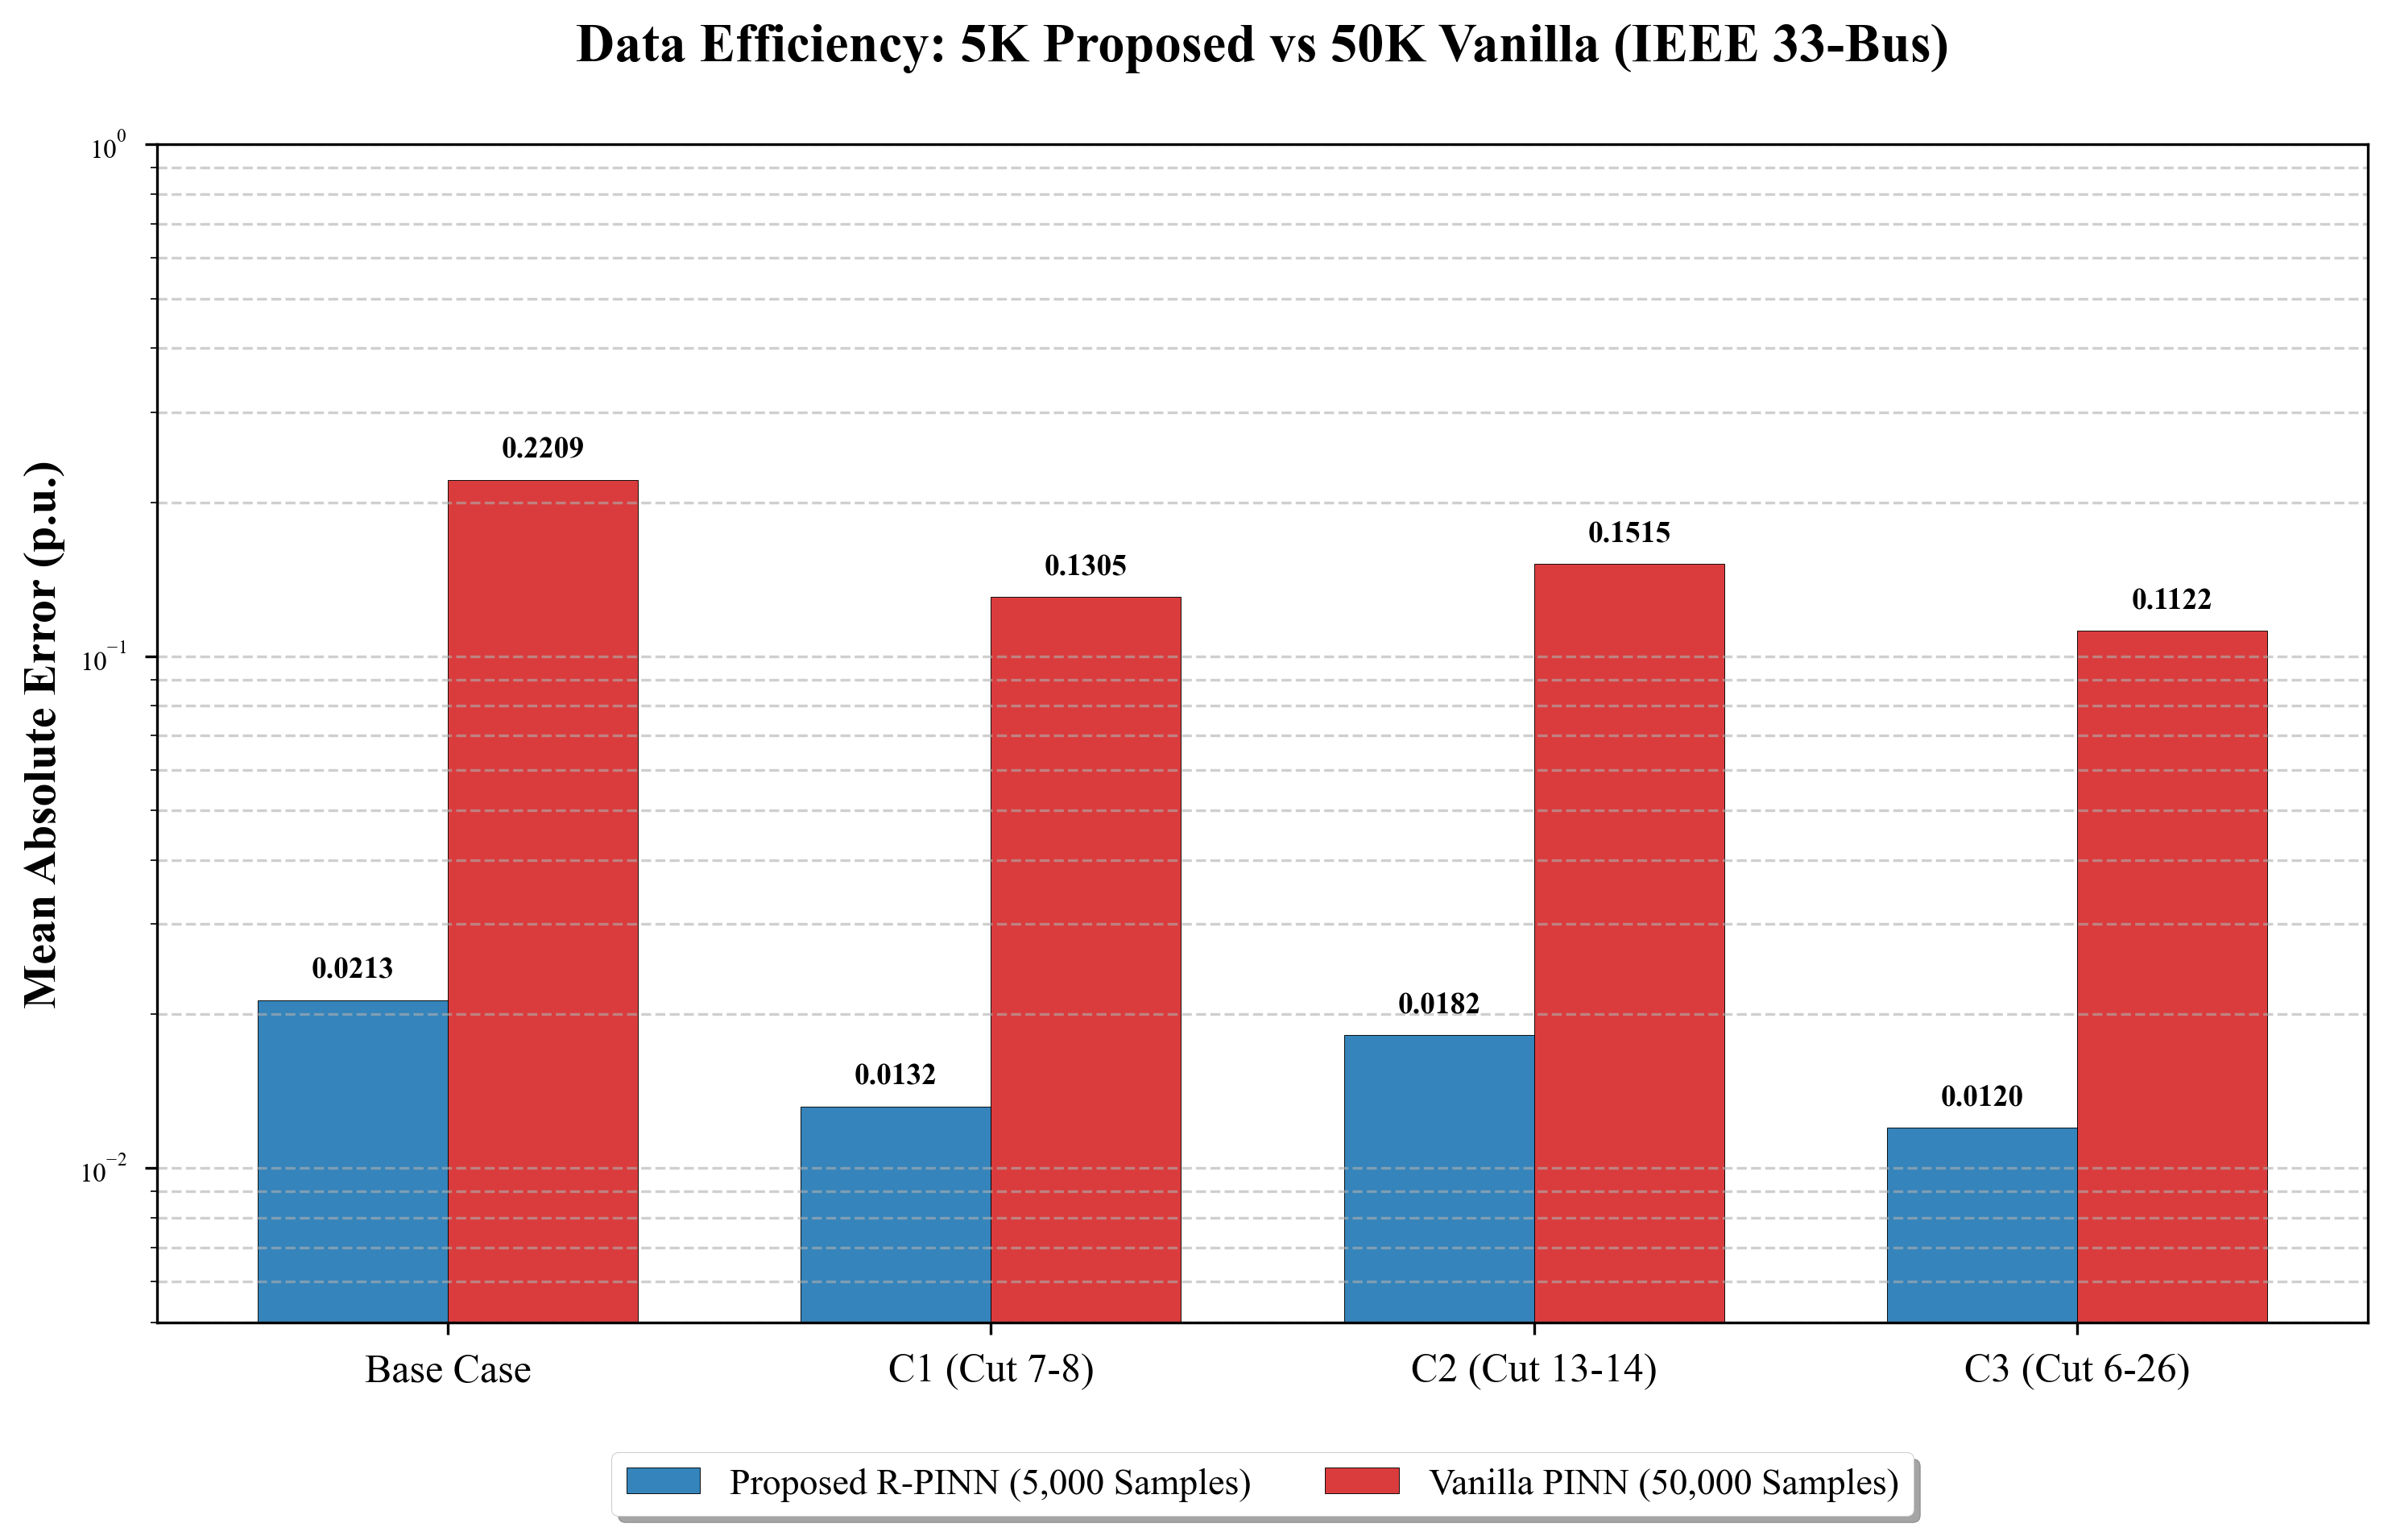

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# ⚙️ 1. 全局学术排版设置 (Times New Roman + 600 DPI)
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.style.use('seaborn-v0_8-paper')

# 场景标签
labels = ['Base Case', 'C1 (Cut 7-8)', 'C2 (Cut 13-14)', 'C3 (Cut 6-26)']
x = np.arange(len(labels))

# ==========================================================
# 📊 2. 图 1: 五万条数据 (50,000 Samples) - 三方会战对比
# ==========================================================
# 数据已根据终端真实跑出结果替换
mae_proposed_50k = [0.0216, 0.0135, 0.0180, 0.0094]
mae_sumloss_50k  = [0.0031, 0.0041, 0.0049, 0.0076]
mae_vanilla_50k  = [0.2209, 0.1305, 0.1515, 0.1122]

width = 0.25
fig1, ax1 = plt.subplots(figsize=(11, 7))

# 绘制柱状图
rects1 = ax1.bar(x - width, mae_proposed_50k, width, label='Proposed R-PINN (Mean-Loss)', color='#1f77b4', edgecolor='black', alpha=0.9)
rects2 = ax1.bar(x, mae_sumloss_50k, width, label='Ablation (Sum-Loss)', color='#ff7f0e', edgecolor='black', alpha=0.9)
rects3 = ax1.bar(x + width, mae_vanilla_50k, width, label='Vanilla PINN (No ARS)', color='#2ca02c', edgecolor='black', alpha=0.9)

# 🚀 核心改进：在柱子上方显示数值（四位小数，不含 E）
def add_labels(ax, rects):
    ax.bar_label(rects, fmt='%.4f', padding=5, fontsize=9, fontweight='bold', rotation=0)

add_labels(ax1, rects1)
add_labels(ax1, rects2)
add_labels(ax1, rects3)

# 🚨 对数轴设置，完美展示 0.2 和 0.003 的量级差距
ax1.set_yscale('log')
ax1.set_ylabel('Mean Absolute Error (p.u.)', fontsize=14, fontweight='bold')
ax1.set_title('Performance Comparison on IEEE 33-Bus (50,000 Samples)', fontsize=16, fontweight='bold', pad=25)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_ylim(1e-3, 1.0) # 调高上限，给数值标签留空间
ax1.grid(axis='y', linestyle='--', alpha=0.6, which='both')
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('mae_33bus_50k_comparison.png', dpi=600, bbox_inches='tight')
print("✅ 第一张神图 (三方会战) 生成完毕！")

# ==========================================================
# 📊 3. 图 2: 降维打击效能 (5k Proposed vs 50k Vanilla)
# ==========================================================
# 提取自 5k 少样本日志
mae_proposed_5k = [0.0213, 0.0132, 0.0182, 0.0120]

width_5k = 0.35
fig2, ax2 = plt.subplots(figsize=(10, 6.5))

rects4 = ax2.bar(x - width_5k/2, mae_proposed_5k, width_5k, label='Proposed R-PINN (5,000 Samples)', color='#1f77b4', edgecolor='black', alpha=0.9)
rects5 = ax2.bar(x + width_5k/2, mae_vanilla_50k, width_5k, label='Vanilla PINN (50,000 Samples)', color='#d62728', edgecolor='black', alpha=0.9)

# 🚀 核心改进：显示数值
add_labels(ax2, rects4)
add_labels(ax2, rects5)

ax2.set_yscale('log')
ax2.set_ylabel('Mean Absolute Error (p.u.)', fontsize=14, fontweight='bold')
ax2.set_title('Data Efficiency: 5K Proposed vs 50K Vanilla (IEEE 33-Bus)', fontsize=16, fontweight='bold', pad=25)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_ylim(5e-3, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.6, which='both')
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('mae_33bus_data_efficiency.png', dpi=600, bbox_inches='tight')
print("✅ 第二张神图 (数据效能打击) 生成完毕！")
plt.show()